**Name:** Manidip Debnath  
**Assignment:** Build and Pre-train Your Own GPT (nanoGPT-style, TinyStories)  
**Run:** Google Colab, NVIDIA T4 GPU, one top-to-bottom run


# Build and Pre-train Your Own GPT

In this assignment you build a GPT-style language model from scratch in PyTorch and **pre-train** it on a corpus of short stories. The code follows the structure of Andrej Karpathy's [nanoGPT](https://github.com/karpathy/nanoGPT) (same module names, same training recipe). It is scaled down so that it trains in a few minutes on a free Google Colab GPU, or in 10–20 minutes on a laptop CPU.

When you finish, you will have written every piece of the pre-training pipeline yourself:

| Stage | What happens | Where |
|---|---|---|
| 1. Data | download raw text | Part 1 (provided) |
| 2. Tokenizer | text → a list of integers | **TODO 1** |
| 3. Batches | cut the token stream into (input, target) pairs | **TODO 2** |
| 4. Model | causal self-attention → transformer block → GPT | **TODO 3 – 7** |
| 5. Training | loss → gradients → AdamW update, with a learning-rate schedule | **TODO 8 – 9** |
| 6. Generation | sample new text one token at a time | **TODO 10** |
| 7. Scaling | tune the model under a fixed compute budget to reach a target loss | **Part 7** |

After about two minutes of GPU training, a half-million-parameter model from this notebook writes text like this (a real, unedited sample):

> *Once upon a time, there was a little girl named Luenie. Lucy was very fast and happy and safe. She lived in a small house with her mom and dad. They had a lot of fun with their best friend.*

It learned this one character at a time, from nothing but raw text: no grammar rules, no labels. The name changes halfway through, and that is typical of a model this small.

### How to work through this notebook

- Run the cells **from top to bottom**. If you restart the runtime, run everything from the top again (*Runtime → Run before*).
- Cells marked **TODO** contain blanks written as `...`. Replace each `...` with code. Most blanks are a single line. Comments next to each blank tell you what it should compute and the shape of the result.
- Every TODO is followed by a **test cell**. Run it. You should see `✅`. If you see `❌`, read the message, fix your code, re-run the TODO cell, then re-run the test.
- An error that mentions **`ellipsis`** (for example `'ellipsis' object has no attribute ...`) means that a `...` blank is still unfilled, in this cell or in an earlier TODO it uses.
- Cells marked **🔒 Do not modify** load the data, count compute and compute your score. Changing them invalidates your score.
- Questions marked **✍️** need a short written answer (2–5 sentences) in the markdown cell below them.

### Where to run it

| Option | How | Default training run |
|---|---|---|
| **Google Colab (recommended)** | Upload this notebook at [colab.research.google.com](https://colab.research.google.com), then *Runtime → Change runtime type → T4 GPU* | ~1–2 min |
| **Your laptop** | Python ≥ 3.9 and `pip install torch numpy matplotlib jupyter`. Apple-silicon Macs use the `mps` GPU backend automatically. | ~2–15 min |
| Colab without a GPU | Works, just slower | ~10–20 min |

### Grading (100 points + up to 10 bonus)

| Part | Points |
|---|---|
| TODOs 1–10, each checked by its test cell | 50 |
| Part 5: the default model reaches validation loss **≤ 1.00** | 10 |
| Part 7: your best model, within the compute budget (see the table in Part 7) | 20 |
| Part 7: experiment log and discussion | 5 |
| ✍️ Written questions Q1–Q6 | 15 |
| Bonus (Part 9) | +10 |

**What to submit:** this notebook **with all outputs visible** (*File → Download → .ipynb*). The final-evaluation cell in Part 8 prints a `SUBMISSION SUMMARY` block; make sure it is there.

---
## Submission notes

**Student:** Manidip Debnath &nbsp;·&nbsp; **Machine:** Google Colab, NVIDIA T4 GPU, one top-to-bottom run

All ten TODOs are implemented and each is followed by its original test cell. Everything marked **➕ Extra** was added on top of the original assignment structure. The extras never modify a 🔒 cell, and the final model comes from `train()` within `FLOP_BUDGET`.

| ➕ Extra | Where | What it adds |
|---|---|---|
| Hardware check | Part 0 | measured GPU throughput, so the runtime estimates are real |
| Baselines | Part 2 | unigram / bigram entropy, to put the model's loss in context |
| Deterministic evaluation | Part 7 | same fixed validation slice as Part 8, so runs can be compared without sampling noise |
| Budget planner + screening sweep | Part 7 | every candidate is checked against `FLOP_BUDGET` first; screening runs use 12% of it |
| Full-budget context-length study | Part 7 | six settings at the full budget, then two fresh seeds for the winner and the baseline |
| Analysis | after Part 8 | loss vs. compute, loss by context position, fraction of generated words that are real words |
| Bonus, Option B | Part 9 | RoPE with causality and relative-position tests, a paired comparison on the fixed slice |
| Appendix A | after Part 9 | seed replication of the RoPE comparison |
| Appendix B | after Appendix A | model size vs. tokens, dropout, context vs. batch, a window-length analysis of the Part 8 score, and RoPE at the full budget |


---
# Part 0 · Setup

The next cell imports the libraries and picks the fastest device available: an NVIDIA GPU (`cuda`), an Apple-silicon GPU (`mps`), or the CPU.

In [1]:
# 🔒 Do not modify
import math, os, time, json, urllib.request
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"PyTorch {torch.__version__} | device: {device}")
if device == "cpu":
    print("No GPU found. Everything still works, training is just slower.")
    print("On Colab: Runtime -> Change runtime type -> T4 GPU, then run from the top.")


def check(condition, message):
    """Raise a readable error when a test fails."""
    if not condition:
        raise AssertionError("❌ " + message)

PyTorch 2.11.0+cu130 | device: cuda


**➕ Extra: hardware check.** Training time depends on the machine, so we measure it once. The number below is the matrix-multiply throughput in GFLOP/s on this device. A full-budget run needs $2\times10^{14}$ FLOPs, but a real training run of this small model reaches only a fraction of the peak, so treat the time estimate as optimistic.

In [2]:
# ➕ Extra: hardware check
print("device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "no GPU", "| python", __import__("sys").version.split()[0])
_a = torch.randn(2048, 2048, device=device); _b = torch.randn(2048, 2048, device=device)
_a @ _b                                  # warm-up
if device == "cuda":
    torch.cuda.synchronize()
_t0 = time.time(); _reps = 20
for _ in range(_reps):
    _a @ _b
if device == "cuda":
    torch.cuda.synchronize()
_gflops = 2 * 2048**3 * _reps / (time.time() - _t0) / 1e9
print(f"matmul throughput: {_gflops:.0f} GFLOP/s")
print(f"ideal time for the Part 7 budget at that speed: {2e14 / (_gflops * 1e9) / 60:.1f} min "
      f"(real training of a model this small is slower: expect 2-5x)")

device: cuda | Tesla T4 | python 3.13.15
matmul throughput: 2838 GFLOP/s
ideal time for the Part 7 budget at that speed: 1.2 min (real training of a model this small is slower: expect 2-5x)


**Troubleshooting**
- *`CERTIFICATE_VERIFY_FAILED` when downloading (Mac with Python from python.org):* run `/Applications/Python\ 3.*/Install\ Certificates.command` in a terminal once, or use Colab.
- *Colab disconnected:* reconnect, then *Runtime → Run all*. The download is cached, and every cell is quick except the training runs.
- *Errors on `mps` (Apple GPU):* add a new cell right below the setup cell containing `device = "cpu"`, then run everything from there again.
- *`CUDA out of memory`:* use a smaller `batch_size` or `block_size`.

---
# Part 1 · The data

### Why short stories and not the whole web?

Modern LLMs are pre-trained on trillions of tokens of web text, for example the [FineWeb](https://huggingface.co/datasets/HuggingFaceFW/fineweb) corpus. Web text is very diverse: code, news, recipes, math, forum posts, many languages. A model with one million parameters trained for a few minutes cannot learn much of that, and its output would look like random word fragments.

We use **[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)** instead (Eldan & Li, 2023): about 2 million short children's stories written by GPT-3.5/GPT-4, using the vocabulary of a 3–4 year old. It was built for exactly our situation. Very small models trained on it produce fluent, grammatical English, so within a few minutes you can see your model learn. The training recipe is exactly the one used for large models; only the data and the model size are smaller. (The optional bonus in Part 9 lets you try real web text and compare.)

### What we download

- **Training text:** the first `TRAIN_MB` megabytes of the TinyStories training file (default 40 MB, about 49,000 stories, 40 million characters).
- **Validation text:** the official TinyStories validation file (22 MB, about 27,000 stories). The model never trains on it. We use it to measure how well the model predicts text it has **not** seen.

Stories are separated by the marker `<|endoftext|>`, the same end-of-document marker GPT-2 uses. The model has to learn when a story ends.

In [3]:
# 🔒 Do not modify (you may change TRAIN_MB in Part 7 if you want more training data)
TRAIN_MB = 40
DATA_DIR = "data"
BASE_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/"
EOT = "<|endoftext|>"


def download(url, path, n_bytes=None):
    """Download a file (or only its first n_bytes) unless we already have it."""
    if os.path.exists(path):
        return
    os.makedirs(os.path.dirname(path), exist_ok=True)
    headers = {"Range": f"bytes=0-{n_bytes - 1}"} if n_bytes else {}
    request = urllib.request.Request(url, headers=headers)
    print(f"downloading {os.path.basename(path)} ...", end=" ", flush=True)
    with urllib.request.urlopen(request) as response, open(path + ".part", "wb") as f:
        while chunk := response.read(1 << 20):
            f.write(chunk)
    os.rename(path + ".part", path)
    print(f"{os.path.getsize(path) / 1e6:.1f} MB")


train_path = os.path.join(DATA_DIR, f"tinystories_train_{TRAIN_MB}MB.txt")
val_path = os.path.join(DATA_DIR, "tinystories_valid.txt")
download(BASE_URL + "TinyStoriesV2-GPT4-train.txt", train_path, n_bytes=TRAIN_MB * 1_000_000)
download(BASE_URL + "TinyStoriesV2-GPT4-valid.txt", val_path)

# The vocabulary: newline + the 95 printable ASCII characters (space ... ~).
VOCAB = ["\n"] + [chr(i) for i in range(32, 127)]
_ALLOWED = set(VOCAB)
_REPLACE = {"“": '"', "”": '"', "‘": "'", "’": "'", "—": "-", "–": "-", "…": "..."}


def load_stories(path, drop_first=False, drop_last=False):
    """Read a file, normalise punctuation, keep only vocabulary characters, split into stories."""
    with open(path, encoding="utf-8", errors="ignore") as f:
        raw = f.read()
    for a, b in _REPLACE.items():
        raw = raw.replace(a, b)
    raw = "".join(ch for ch in raw if ch in _ALLOWED)
    stories = [s.strip() for s in raw.split(EOT)]
    stories = [s for s in stories if s]
    if drop_first:  # the validation file starts in the middle of a story
        stories = stories[1:]
    if drop_last:   # our partial download ends in the middle of a story
        stories = stories[:-1]
    return stories


train_stories = load_stories(train_path, drop_last=True)
val_stories = load_stories(val_path, drop_first=True)
train_text = "".join(s + "\n" + EOT + "\n" for s in train_stories)
val_text = "".join(s + "\n" + EOT + "\n" for s in val_stories)

print(f"train: {len(train_stories):,} stories, {len(train_text):,} characters")
print(f"val:   {len(val_stories):,} stories, {len(val_text):,} characters")

downloading tinystories_train_40MB.txt ... 40.0 MB
downloading tinystories_valid.txt ... 22.5 MB
train: 48,793 stories, 39,963,595 characters
val:   27,629 stories, 22,482,104 characters


Look at the data before you model it. Always.

In [4]:
print(train_text[:1500])

Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, "Wow, that is a really amazing vase! Can I buy it?" 
The shopkeeper smiled and said, "Of course you can. You can take it home and show all your friends how amazing it is!"
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!
<|endoftext|>
Once upon a time, there was a reliable otter named Ollie. He lived in a river with his family. They all loved to play and swim together.
One day, Ollie's mom said, "Ollie, hurry and get some fish for dinner!" Ollie swam fast to catch fish. He saw his frie

---
# Part 2 · Tokenization

A neural network works on numbers, not strings. A **tokenizer** turns text into a list of integer *token ids* and back:

$$\text{"Hi!"} \;\xrightarrow{\text{encode}}\; [41, 74, 2] \;\xrightarrow{\text{decode}}\; \text{"Hi!"}$$

**Character-level vs. subword tokens.** GPT-2, GPT-4 and Llama use *subword* tokenizers (Byte-Pair Encoding, BPE) with 50,000–200,000 tokens, where a token is usually a whole word or a piece of one (`" upon"`, `" time"`, `"ing"`). We use the simplest possible tokenizer: **one token per character**. Our vocabulary `VOCAB` has $|V| = 96$ entries (newline plus the 95 printable ASCII characters).

| | character-level (ours) | BPE (GPT-2) |
|---|---|---|
| vocabulary size $\lvert V\rvert$ | 96 | 50,257 |
| tokens for `"Once upon a time"` | 16 | 4 |
| size of the output layer ($\lvert V\rvert \times d$, with $d = 128$) | 12 K parameters | 6.4 M parameters |

A character-level model needs longer sequences to cover the same text, but its output layer is tiny. That is why it is the right choice when compute is small. Everything else in the pipeline is identical.

### TODO 1 · Build the tokenizer (4 points)

Token id `i` is the character `VOCAB[i]`. Build two lookup tables and the two functions:

- `stoi` ("string to integer"): a dict mapping each character to its index in `VOCAB`, e.g. `stoi["\n"] == 0`, `stoi[" "] == 1`
- `itos` ("integer to string"): the reverse dict, e.g. `itos[1] == " "`
- `encode(s)`: a string → a list of ints
- `decode(ids)`: a list of ints → a string

*Hint:* `enumerate(VOCAB)` gives you `(index, character)` pairs. A dict comprehension looks like `{key: value for ... in ...}`, and `"".join(list_of_strings)` concatenates strings.

In [5]:
# TODO 1
stoi = {ch: i for i, ch in enumerate(VOCAB)}  # character -> id
itos = {i: ch for i, ch in enumerate(VOCAB)}  # id -> character


def encode(s):
    """String -> list of token ids."""
    return [stoi[c] for c in s]


def decode(ids):
    """List of token ids -> string."""
    return "".join(itos[i] for i in ids)


vocab_size = len(VOCAB)
print("vocab_size =", vocab_size)
print(encode("Hi!"))

vocab_size = 96
[41, 74, 2]


In [6]:
# Test for TODO 1
check(isinstance(stoi, dict) and isinstance(itos, dict), "stoi and itos should be dicts.")
check(len(stoi) == 96 and len(itos) == 96, "stoi and itos should each have 96 entries.")
check(stoi["\n"] == 0 and stoi[" "] == 1 and stoi["A"] == 34, "stoi should map VOCAB[i] -> i.")
check(itos[0] == "\n" and itos[34] == "A", "itos should map i -> VOCAB[i].")
check(encode("Hi!") == [41, 74, 2], f"encode('Hi!') should be [41, 74, 2], got {encode('Hi!')}.")
sample = train_text[:1000]
check(decode(encode(sample)) == sample, "decode(encode(s)) should give back s exactly.")
print("✅ TODO 1 passed")

✅ TODO 1 passed


Now we encode the entire corpus. Python loops over 40 million characters are slow, so the next cell uses a vectorized NumPy lookup table built from **your** `stoi`, and checks that it agrees with your `encode`. We store the ids as `uint8` (1 byte each) to save memory, since all ids are < 256.

In [7]:
# 🔒 Do not modify
_lut = np.zeros(256, dtype=np.uint8)
for ch, i in stoi.items():
    _lut[ord(ch)] = i


def encode_fast(text):
    return torch.from_numpy(_lut[np.frombuffer(text.encode("ascii"), dtype=np.uint8)].copy())


train_data = encode_fast(train_text)
val_data = encode_fast(val_text)
check(train_data[:5000].tolist() == encode(train_text[:5000]), "encode_fast disagrees with your encode().")
print(f"train_data: {train_data.shape[0]:,} tokens | val_data: {val_data.shape[0]:,} tokens | dtype {train_data.dtype}")
print("first 20 ids:", train_data[:20].tolist())
print("decoded     :", repr(decode(train_data[:20].tolist())))

train_data: 39,963,595 tokens | val_data: 22,482,104 tokens | dtype torch.uint8
first 20 ids: [48, 79, 68, 70, 1, 86, 81, 80, 79, 1, 66, 1, 85, 74, 78, 70, 1, 85, 73, 70]
decoded     : 'Once upon a time the'


### ➕ Extra: how good is "not knowing anything"? Baselines for the loss

Before training a transformer it is worth knowing what simple statistics already achieve. We measure three baselines in nats per character on the **validation** data:

| baseline | what it knows | loss |
|---|---|---|
| uniform | nothing: every character equally likely | $\ln 96$ |
| unigram | how often each character occurs | cross-entropy of the training character frequencies on the validation text |
| bigram | the previous character only | cross-entropy of $p(x_t \mid x_{t-1})$ estimated on the training text |

Everything the GPT achieves *below the bigram line* comes from using more than one character of context: spelling, words, grammar.

uniform  loss 4.564 nats/char | perplexity  96.00 | 6.58 bits/char
unigram  loss 3.081 nats/char | perplexity  21.77 | 4.44 bits/char
bigram   loss 2.280 nats/char | perplexity   9.78 | 3.29 bits/char


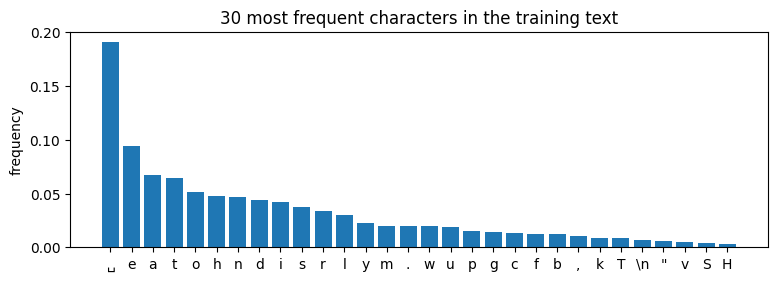

In [8]:
# ➕ Extra: unigram and bigram baselines (counts from train_data, evaluated on val_data)
tr, va = train_data.long(), val_data.long()
V = vocab_size

uni = torch.bincount(tr, minlength=V).double() + 1.0            # +1 smoothing so nothing has probability 0
uni = uni / uni.sum()
unigram_loss = -uni.log()[va].mean().item()

big = torch.zeros(V, V, dtype=torch.float64)
big.index_put_((tr[:-1], tr[1:]), torch.ones(len(tr) - 1, dtype=torch.float64), accumulate=True)
big = (big + 0.1) / (big + 0.1).sum(dim=1, keepdim=True)         # p(next | previous), light smoothing
bigram_loss = -big.log()[va[:-1], va[1:]].mean().item()

baselines = {"uniform": math.log(V), "unigram": unigram_loss, "bigram": bigram_loss}
for k, v in baselines.items():
    print(f"{k:8s} loss {v:.3f} nats/char | perplexity {math.exp(v):6.2f} | {v / math.log(2):.2f} bits/char")

freq = torch.bincount(tr, minlength=V).double(); freq /= freq.sum()
order = freq.argsort(descending=True)[:30]
plt.figure(figsize=(9, 2.8))
plt.bar(range(30), freq[order].numpy())
plt.xticks(range(30), [repr(itos[i.item()])[1:-1] if itos[i.item()] != " " else "␣" for i in order])
plt.ylabel("frequency"); plt.title("30 most frequent characters in the training text"); plt.show()

---
# Part 3 · Training examples: predict the next token

### The language-modeling objective

A language model gives a probability to a sequence of tokens $x_1, \dots, x_n$. By the chain rule of probability, that is a product of **next-token** probabilities:

$$p(x_1, \dots, x_n) = \prod_{t=1}^{n} p(x_t \mid x_1, \dots, x_{t-1})$$

So all we need is a model that, given the tokens so far, outputs a probability distribution over the next token. We train it by minimizing the **cross-entropy loss**: the average negative log-probability that the model assigns to the token that actually comes next:

$$\mathcal{L}(\theta) = -\frac{1}{N} \sum_{t=1}^{N} \log p_\theta\left(x_{t+1} \mid x_1, \dots, x_t\right)$$

No human labels are needed: the text is its own label. This is **self-supervised** learning, and it is what "pre-training" means.

### From a token stream to (input, target) pairs

We pick a random window of `block_size` + 1 consecutive tokens. The input `x` is the first `block_size` tokens, and the target `y` is the same window **shifted one position to the left**:

```
text   :  O  n  c  e     u  p  o  n
x      :  O  n  c  e     u  p  o        (block_size = 8)
y      :  n  c  e     u  p  o  n
```

Position $t$ of `y` is the token that follows positions $0 \dots t$ of `x`. One window of length $T$ therefore gives $T$ training examples at once: predict `n` from `O`, predict `c` from `On`, ..., predict `n` from `Once upo`. We stack `batch_size` random windows into a batch, so `x` and `y` both have shape `(B, T)`.

### TODO 2 · `get_batch` (5 points)

`ix` already holds `batch_size` random start positions. Build `x` and `y` by slicing `data` at each start position `i` and stacking the slices with `torch.stack`.

In [9]:
# TODO 2
def get_batch(split, batch_size, block_size):
    """Return a random batch (x, y), each of shape (batch_size, block_size), on `device`."""
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))  # random start positions
    x = torch.stack([data[i : i + block_size] for i in ix])  # inputs
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])  # targets
    return x.long().to(device), y.long().to(device)


xb, yb = get_batch("train", batch_size=4, block_size=16)
print("x shape:", tuple(xb.shape), "| y shape:", tuple(yb.shape))
for b in range(2):
    print("x:", repr(decode(xb[b].tolist())))
    print("y:", repr(decode(yb[b].tolist())))

x shape: (4, 16) | y shape: (4, 16)
x: 'ed that sharing '
y: 'd that sharing i'
x: ' and more.\n"Look'
y: 'and more.\n"Look,'


In [10]:
# Test for TODO 2
torch.manual_seed(0)
xb, yb = get_batch("train", batch_size=8, block_size=32)
check(tuple(xb.shape) == (8, 32) and tuple(yb.shape) == (8, 32), f"x and y should have shape (8, 32), got {tuple(xb.shape)} and {tuple(yb.shape)}.")
check(xb.dtype == torch.long and yb.dtype == torch.long, "x and y should be int64 (torch.long).")
check(torch.equal(xb[:, 1:], yb[:, :-1]), "y should be x shifted left by one: y[:, :-1] must equal x[:, 1:].")
torch.manual_seed(0)
ix = torch.randint(len(train_data) - 32 - 1, (8,))  # the same start positions get_batch drew above
for b, i in enumerate(ix.tolist()):
    check(torch.equal(xb[b].cpu(), train_data[i : i + 32].long()), "row b of x should be train_data[i : i + block_size], with i = ix[b].")
    check(torch.equal(yb[b].cpu(), train_data[i + 1 : i + 33].long()), "row b of y should be train_data[i + 1 : i + 1 + block_size].")
print("✅ TODO 2 passed")

✅ TODO 2 passed


---
# Part 4 · The model

Here is the whole model. Every box is a module you will implement:

```
token ids (B, T)
   │
   ├─ token embedding  wte: id -> vector (d)            ┐
   ├─ position embedding wpe: position -> vector (d)    ┘  add  ->  x  (B, T, d)
   │
   ├─ Block 1:   x = x + Attention(LayerNorm(x))        "tokens talk to each other"
   │             x = x + MLP(LayerNorm(x))              "each token thinks on its own"
   ├─ Block 2 ... Block n_layer  (same structure, separate weights)
   │
   ├─ final LayerNorm  ln_f
   └─ lm_head: vector (d) -> one score (logit) per vocabulary entry     (B, T, |V|)
```

Notation used below: $B$ = batch size, $T$ = sequence length (≤ `block_size`), $d$ = `n_embd` (model width), $h$ = `n_head`, $d_k = d/h$ (width of one head).

The model's hyperparameters live in one small config object:

In [11]:
# 🔒 Do not modify (you choose your own values in Part 7 by creating a new GPTConfig)
@dataclass
class GPTConfig:
    vocab_size: int = 96     # |V|
    block_size: int = 128    # maximum context length T
    n_layer: int = 4         # number of transformer blocks
    n_head: int = 4          # number of attention heads h
    n_embd: int = 128        # model width d
    dropout: float = 0.0     # dropout probability (0 = off)

## 4.1 Scaled dot-product attention with a causal mask

Every token's vector $x_i$ produces three vectors through learned linear maps: a **query** $q_i = x_i W_Q$ ("what am I looking for?"), a **key** $k_i = x_i W_K$ ("what do I contain?") and a **value** $v_i = x_i W_V$ ("what do I pass on if selected?"). Stacking the rows gives matrices $Q, K, V \in \mathbb{R}^{T \times d_k}$, and

$$\text{Attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}} + M\right) V, \qquad M_{ij} = \begin{cases} 0 & j \le i \\ -\infty & j > i \end{cases}$$

Step by step, for a sequence of length $T$:

1. **Scores** $S = QK^\top / \sqrt{d_k}$, shape $T \times T$. Entry $S_{ij}$ says how much token $i$ wants to look at token $j$. Dividing by $\sqrt{d_k}$ keeps the scores at a reasonable scale, so the softmax does not saturate.
2. **Causal mask** $M$: token $i$ may only look at tokens $j \le i$ (the past and itself). We set the scores of all future positions to $-\infty$. After the softmax they become exactly 0. Without this mask the model could read the answer (the next token) during training.
3. **Softmax over each row**: $A_{ij} = e^{S_{ij}} / \sum_{j'} e^{S_{ij'}}$. Every row of $A$ is a probability distribution: the weights are ≥ 0 and sum to 1.
4. **Weighted sum** $A V$: the output for token $i$ is $\sum_j A_{ij} v_j$, a mix of the value vectors of the tokens it attends to.

In code, `q`, `k`, `v` have shape `(B, h, T, d_k)`: a batch of $B$ sequences, each with $h$ heads. PyTorch's `@` operator does matrix multiplication over the **last two** dimensions and broadcasts over the leading ones, so the same code handles all batches and heads at once.

For the mask, `torch.tril` gives a lower-triangular matrix. For $T=4$, `mask` is:
```
[[ True, False, False, False],
 [ True,  True, False, False],
 [ True,  True,  True, False],
 [ True,  True,  True,  True]]      True = allowed to look
```

### TODO 3 · `causal_attention` (6 points)

Useful functions: `k.transpose(-2, -1)` swaps the last two dimensions, `math.sqrt`, `scores.masked_fill(condition, value)` writes `value` wherever `condition` is `True` (so pass `~mask`, meaning "not allowed"), and `F.softmax(scores, dim=-1)`.

In [12]:
# TODO 3
def causal_attention(q, k, v):
    """
    q, k, v: tensors of shape (B, h, T, d_k)
    returns: tensor of shape (B, h, T, d_k)
    """
    T, d_k = q.size(-2), q.size(-1)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool, device=q.device))  # (T, T), True = allowed

    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)  # (B, h, T, T)
    scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)  # (B, h, T, T)
    out = weights @ v  # (B, h, T, d_k)
    return out

In [13]:
# Test for TODO 3
torch.manual_seed(0)
q, k, v = (torch.randn(2, 3, 5, 8) for _ in range(3))
out = causal_attention(q, k, v)
check(isinstance(out, torch.Tensor) and tuple(out.shape) == (2, 3, 5, 8), "output should have shape (B, h, T, d_k) = (2, 3, 5, 8).")
check(torch.allclose(out[:, :, 0], v[:, :, 0], atol=1e-5), "the first token can only see itself, so its output must equal v[:, :, 0]. Is the mask applied?")
reference = F.scaled_dot_product_attention(q, k, v, is_causal=True)
check(torch.allclose(out, reference, atol=1e-5), "output does not match PyTorch's reference attention. Check the sqrt(d_k) scaling and the softmax dimension.")
print("✅ TODO 3 passed")

✅ TODO 3 passed


## 4.2 Multi-head attention

One attention head can only compute one kind of "who looks at whom" pattern. **Multi-head attention** runs $h$ heads in parallel, each with its own $W_Q, W_K, W_V$ of width $d_k = d/h$, then concatenates their outputs and mixes them with an output matrix $W_O$:

$$\text{MHA}(X) = \operatorname{Concat}(\text{head}_1, \dots, \text{head}_h)\, W_O, \qquad \text{head}_i = \text{Attention}(X W_Q^{(i)}, X W_K^{(i)}, X W_V^{(i)})$$

As nanoGPT does, we compute all queries, keys and values of all heads with **one** linear layer `c_attn` (output width $3d$), split the result into `q, k, v` (each `(B, T, d)`), and then split the last dimension into heads:

$$(B, T, d) \xrightarrow{\texttt{.view(B, T, h, d_k)}} (B, T, h, d_k) \xrightarrow{\texttt{.transpose(1, 2)}} (B, h, T, d_k)$$

After attention we undo this ("merge the heads", provided) and apply $W_O$ (`c_proj`).

### TODO 4 · `CausalSelfAttention.forward` (5 points)

Reshape `q`, `k` and `v` into heads, exactly as shown above, then call your `causal_attention`.

In [14]:
# TODO 4
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)  # W_Q, W_K, W_V for all heads
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)      # W_O
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        B, T, C = x.shape                  # C = n_embd = d
        h, d_k = self.n_head, C // self.n_head
        q, k, v = self.c_attn(x).split(C, dim=2)  # each (B, T, C)

        q = q.view(B, T, h, d_k).transpose(1, 2)  # (B, h, T, d_k)
        k = k.view(B, T, h, d_k).transpose(1, 2)
        v = v.view(B, T, h, d_k).transpose(1, 2)
        y = causal_attention(q, k, v)  # (B, h, T, d_k)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # merge heads: (B, h, T, d_k) -> (B, T, C)
        return self.resid_dropout(self.c_proj(y))

In [15]:
# Test for TODO 4
torch.manual_seed(0)
cfg = GPTConfig(n_embd=16, n_head=4, block_size=8)
attn = CausalSelfAttention(cfg)
x = torch.randn(2, 6, 16)
y = attn(x)
check(isinstance(y, torch.Tensor) and tuple(y.shape) == (2, 6, 16), f"output should have shape (2, 6, 16), got {getattr(y, 'shape', None)}.")
x2 = x.clone()
x2[:, 4:] = torch.randn(2, 2, 16)  # change only the last two tokens
check(torch.allclose(attn(x2)[:, :4], y[:, :4], atol=1e-6), "changing future tokens changed the output at earlier positions: attention is not causal.")
q, k, v = attn.c_attn(x).split(16, dim=2)
heads = lambda t: t.view(2, 6, 4, 4).transpose(1, 2)
ref = F.scaled_dot_product_attention(heads(q), heads(k), heads(v), is_causal=True).transpose(1, 2).reshape(2, 6, 16)
check(torch.allclose(y, attn.c_proj(ref), atol=1e-5), "output does not match the reference multi-head attention. Check the view/transpose into heads.")
print("✅ TODO 4 passed")

✅ TODO 4 passed


## 4.3 The feed-forward network (MLP)

Attention moves information **between** tokens. The MLP then processes **each token on its own** (the same small network is applied at every position):

$$\text{MLP}(x) = W_2\, \operatorname{GELU}(W_1 x + b_1) + b_2, \qquad W_1 \in \mathbb{R}^{4d \times d},\; W_2 \in \mathbb{R}^{d \times 4d}$$

It expands the width from $d$ to $4d$, applies the non-linearity GELU (a smooth version of ReLU), and projects back to $d$. About two thirds of a GPT's parameters live in these MLPs.

### TODO 5 · `MLP.forward` (3 points)

Apply the layers in order: `c_fc` → `gelu` → `c_proj` → `dropout`.

In [16]:
# TODO 5
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)    # W_1, b_1
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)  # W_2, b_2
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.dropout(self.c_proj(self.gelu(self.c_fc(x))))  # (B, T, d)
        return x

In [17]:
# Test for TODO 5
torch.manual_seed(0)
mlp = MLP(GPTConfig(n_embd=16))
x = torch.randn(2, 5, 16)
y = mlp(x)
check(isinstance(y, torch.Tensor) and tuple(y.shape) == (2, 5, 16), "output should have the same shape as the input, (2, 5, 16).")
check(torch.allclose(y, mlp.c_proj(F.gelu(mlp.c_fc(x))), atol=1e-6), "output should be c_proj(gelu(c_fc(x))).")
print("✅ TODO 5 passed")

✅ TODO 5 passed


## 4.4 The transformer block

A block wraps attention and the MLP with two ideas that make deep networks trainable:

- **Residual connections.** Each sub-layer computes a *correction* that is **added** to its input: $x \leftarrow x + f(x)$. The vector $x$ that flows through all blocks is called the *residual stream*. Gradients flow straight through the additions, so even deep stacks train well.
- **Layer normalization.** Before each sub-layer, every token's vector is normalized to zero mean and unit variance over its $d$ features, then scaled and shifted by learned $\gamma, \beta$:
  $$\operatorname{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta, \qquad \mu = \frac{1}{d}\sum_{j=1}^{d} x_j, \quad \sigma^2 = \frac{1}{d}\sum_{j=1}^{d} (x_j - \mu)^2$$

GPT-2 and nanoGPT use the **pre-norm** arrangement:

$$x \leftarrow x + \operatorname{Attention}(\operatorname{LN}_1(x)), \qquad x \leftarrow x + \operatorname{MLP}(\operatorname{LN}_2(x))$$

### TODO 6 · `Block.forward` (4 points)

In [18]:
# TODO 6
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))  # residual + attention
        x = x + self.mlp(self.ln_2(x))  # residual + MLP
        return x

In [19]:
# Test for TODO 6
torch.manual_seed(0)
block = Block(GPTConfig(n_embd=16, n_head=4))
x = torch.randn(2, 5, 16)
y = block(x)
check(isinstance(y, torch.Tensor) and tuple(y.shape) == (2, 5, 16), "output should have shape (2, 5, 16).")
h = x + block.attn(block.ln_1(x))
check(torch.allclose(y, h + block.mlp(block.ln_2(h)), atol=1e-5), "output should be x + attn(ln_1(x)), followed by x + mlp(ln_2(x)).")
print("✅ TODO 6 passed")

✅ TODO 6 passed


## 4.5 The full GPT

Putting it together:

1. **Embeddings.** `wte` (word/token embedding) is a learned table with one $d$-dimensional vector per vocabulary entry. `wpe` (position embedding) is a learned table with one vector per position $0 \dots$ `block_size`−1. Attention by itself does not know the order of the tokens, so the position vector tells the model *where* each token is. The input to the first block is their sum: $x = \text{wte}[\text{idx}] + \text{wpe}[0, 1, \dots, T-1]$.
2. **Blocks.** Pass $x$ through the `n_layer` blocks in order.
3. **Output.** Apply the final LayerNorm `ln_f`, then `lm_head`, a linear map from $d$ to $|V|$. It gives one score (**logit**) per vocabulary entry at every position. Softmax turns logits into next-token probabilities: $p(\text{next} = i) = e^{z_i} / \sum_j e^{z_j}$.
4. **Loss.** Cross-entropy between the logits and the targets. `F.cross_entropy` expects logits of shape `(N, |V|)` and targets of shape `(N,)`, so first flatten the batch and time dimensions together: `(B, T, |V|) → (B·T, |V|)` and `(B, T) → (B·T,)`. `F.cross_entropy` applies the softmax and the $-\log$ for you.

Two details are provided for you:
- **Weight tying:** `lm_head` shares its weight matrix with `wte` (GPT-2 does this). Reading a token and writing a token use the same table, which saves parameters.
- **Initialization:** weights start as small random numbers ($\mathcal{N}(0, 0.02^2)$, as in GPT-2), so at the start every token gets roughly the same probability.

### TODO 7 · `GPT.forward` (8 points)

Useful: `torch.arange(T, device=idx.device)` gives the positions `[0, 1, ..., T-1]`; `tensor.view(-1, n)` flattens all but the last dimension; `tensor.view(-1)` flattens everything.

In [20]:
# TODO 7
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)   # token embedding
        self.wpe = nn.Embedding(config.block_size, config.n_embd)   # position embedding
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight  # weight tying

        # GPT-2 initialization: N(0, 0.02^2) everywhere, smaller for layers that write to the residual stream
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("c_proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        """
        idx:     (B, T) token ids, T <= block_size
        targets: (B, T) token ids, or None
        returns: logits (B, T, vocab_size), and the loss (a scalar) if targets are given
        """
        B, T = idx.shape
        assert T <= self.config.block_size, f"sequence length {T} > block_size {self.config.block_size}"
        pos = torch.arange(T, device=idx.device)  # (T,)

        tok_emb = self.wte(idx)  # (B, T, d)
        pos_emb = self.wpe(pos)  # (T, d)
        x = self.drop(tok_emb + pos_emb)  # (B, T, d)  broadcasting adds pos_emb to every sequence
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [21]:
# Test for TODO 7
torch.manual_seed(0)
cfg = GPTConfig(vocab_size=vocab_size, block_size=32, n_layer=2, n_head=4, n_embd=32)
m = GPT(cfg)
xb, yb = get_batch("train", batch_size=4, block_size=32)
m = m.to(device)
logits, loss = m(xb, yb)
check(isinstance(logits, torch.Tensor) and tuple(logits.shape) == (4, 32, vocab_size), f"logits should have shape (4, 32, {vocab_size}), got {getattr(logits, 'shape', None)}.")
check(isinstance(loss, torch.Tensor) and loss.dim() == 0, "loss should be a scalar tensor.")
check(abs(loss.item() - math.log(vocab_size)) < 0.3, f"an untrained model should have loss close to ln({vocab_size}) = {math.log(vocab_size):.2f}, got {loss.item():.2f}.")
logits_only, no_loss = m(xb)
check(no_loss is None, "loss should be None when targets is None.")
x2 = xb.clone()
x2[:, 20:] = (x2[:, 20:] + 1) % vocab_size
check(torch.allclose(m(x2)[0][:, :20], logits[:, :20], atol=1e-5), "changing tokens at positions >= 20 changed the logits at earlier positions: the model is not causal.")
check(torch.allclose(loss, F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1)), atol=1e-5), "loss should be the cross-entropy between the flattened logits and targets.")
m.zero_grad()
loss.backward()
check(m.wpe.weight.grad is not None and m.wpe.weight.grad.abs().sum() > 0, "no gradient reached the position embedding. Did you add pos_emb?")
check(all(b.ln_1.weight.grad is not None for b in m.blocks), "no gradient reached some blocks. Did you apply every block?")
print(f"initial loss {loss.item():.3f} vs. uniform guess ln({vocab_size}) = {math.log(vocab_size):.3f}")
print("✅ TODO 7 passed")

initial loss 4.553 vs. uniform guess ln(96) = 4.564
✅ TODO 7 passed


**Sanity check you just passed:** before training, the model knows nothing, so it spreads its probability almost evenly over all $|V| = 96$ characters. The probability of the correct character is then about $1/96$, and the loss is $-\log(1/96) = \ln 96 \approx 4.56$. Checking the initial loss against $\ln |V|$ is one of the most useful debugging habits in deep learning. If it is far off, you have a bug.

### ✍️ Q1 (2 points)
The initial loss of our model is about $\ln 96 \approx 4.56$. (a) What would the initial loss be for a model with GPT-2's vocabulary of 50,257 tokens? (b) Suppose instead your untrained model started with a loss of 25. What would that tell you about its output probabilities?

*Your answer:*

**(a)** With GPT-2's vocabulary an untrained model that spreads its probability evenly gives each token probability $1/50257$, so the initial loss is $\ln 50257 \approx 10.83$ nats (about 15.6 bits), compared with $\ln 96 \approx 4.56$ for our model. The bigger the vocabulary, the more a model has to learn before it beats a blind guess.

**(b)** A loss of 25 means that on average the correct token gets probability about $e^{-25} \approx 1.4\times10^{-11}$. That is *far worse than a uniform guess* ($1/96 \approx 0.0104$). So the model is not merely ignorant, it is **confidently wrong**: its logits are huge and put almost all the probability on wrong tokens. That points to a bug or a bad initialization (weights with too large a scale, a missing $\sqrt{d_k}$ scaling, or inputs and targets that are misaligned). A healthy network starts with small logits and a loss near $\ln|V|$.

### ✍️ Q2 (3 points)
(a) Explain in your own words what would go wrong if we **removed the causal mask** from `causal_attention` and trained the model. What would happen to the training loss, and what would happen when we try to generate text? (b) Why do we divide the scores by $\sqrt{d_k}$? *(Hint: if the entries of $q$ and $k$ are independent with mean 0 and variance 1, what is the variance of $q \cdot k = \sum_{j=1}^{d_k} q_j k_j$?)*

*Your answer:*

**(a)** Without the mask, position $t$ can attend to position $t+1$, and the token at $t+1$ is exactly the target $y_t$ the model is asked to predict. The model learns to **copy the answer from the input** instead of predicting it. The training loss therefore falls very quickly towards 0, and a validation loss computed with the same unmasked attention would look excellent as well, but it would be meaningless. When we generate text, the next token does not exist yet, so there is nothing to copy; the model never learned to predict from the past alone, and its samples are essentially garbage.

**(b)** If the entries of $q$ and $k$ are independent with mean 0 and variance 1, every product $q_jk_j$ has mean 0 and variance 1, and $\operatorname{Var}(q\cdot k)=\sum_{j=1}^{d_k}\operatorname{Var}(q_jk_j)=d_k$. So the standard deviation of a score is $\sqrt{d_k}$ and grows with the head size. Large scores make the softmax almost one-hot: it saturates, and its gradient is close to 0, so training stalls. Dividing by $\sqrt{d_k}$ brings the variance of the scores back to 1 whatever $d_k$ is.

Let's build the default model and count its parameters.

In [22]:
torch.manual_seed(1337)
model = GPT(GPTConfig()).to(device)
print(model.config)
print(f"parameters: {model.num_params():,}")
for name, p in list(model.named_parameters())[:8]:
    print(f"  {name:28s} {tuple(p.shape)}")
print("  ...")

GPTConfig(vocab_size=96, block_size=128, n_layer=4, n_head=4, n_embd=128, dropout=0.0)
parameters: 822,016
  wte.weight                   (96, 128)
  wpe.weight                   (128, 128)
  blocks.0.ln_1.weight         (128,)
  blocks.0.ln_1.bias           (128,)
  blocks.0.attn.c_attn.weight  (384, 128)
  blocks.0.attn.c_attn.bias    (384,)
  blocks.0.attn.c_proj.weight  (128, 128)
  blocks.0.attn.c_proj.bias    (128,)
  ...


### ✍️ Q3 (2 points)
Each block has about $12d^2$ parameters (ignoring biases and LayerNorm): $4d^2$ in attention (`c_attn` is $d \times 3d$, `c_proj` is $d \times d$) and $8d^2$ in the MLP. Use this to estimate the parameter count of the default model ($d = 128$, 4 layers, $|V| = 96$, `block_size` = 128, remember the two embedding tables) and compare it with the printed number. Where does the small difference come from?

*Your answer:*

Blocks: $4 \times 12 d^2 = 4 \times 12 \times 128^2 = 786{,}432$. Embeddings: `wte` $= 96\times128 = 12{,}288$ and `wpe` $= 128\times128 = 16{,}384$, together $28{,}672$ (`lm_head` is tied to `wte`, so it adds nothing). The estimate is $786{,}432 + 28{,}672 = \mathbf{815{,}104}$, and the model prints **822,016**.

The difference of $6{,}912$ parameters is exactly what the estimate ignores, the biases and LayerNorm parameters. Per block: biases of `c_attn` ($3\cdot128=384$), `c_proj` (128), `c_fc` ($4\cdot128=512$) and the MLP's `c_proj` (128) give $1{,}152$, and two LayerNorms with $\gamma$ and $\beta$ give $2\cdot2\cdot128=512$, so $1{,}664$ per block, $6{,}656$ for four blocks. The final LayerNorm adds $256$: $6{,}656+256=6{,}912$ ✓.

---
# Part 5 · Training

## 5.1 The optimizer and the learning-rate schedule

Training repeats one step many times:

1. sample a batch $(x, y)$,
2. compute the loss $\mathcal{L}$ (the forward pass),
3. compute the gradient $\nabla_\theta \mathcal{L}$ of the loss with respect to every parameter (the backward pass, `loss.backward()`),
4. update the parameters.

We use **AdamW**, the standard optimizer for transformers. It keeps a running average of each parameter's gradient (momentum) and of its squared gradient, so every parameter gets its own adaptive step size. It also applies *weight decay*, which pulls the weights slightly toward 0 at each step (a form of regularization). We also **clip** the gradient: if its total norm $\|g\|$ exceeds 1.0, we rescale it, $g \leftarrow g \cdot 1.0 / \|g\|$. This protects training from an occasional huge gradient.

**Learning-rate schedule.** The learning rate $\eta$ is the size of each update. A constant learning rate is rarely best. GPT models use **linear warmup followed by cosine decay**:

$$\eta(s) = \begin{cases} \eta_{\max} \cdot \dfrac{s + 1}{s_{\text{warm}}} & \text{if } s < s_{\text{warm}} \quad\text{(warmup)} \\[2ex] \eta_{\min} + \dfrac{1}{2}\left(\eta_{\max} - \eta_{\min}\right)\left(1 + \cos(\pi \cdot r)\right), \quad r = \dfrac{s - s_{\text{warm}}}{s_{\max} - s_{\text{warm}}} & \text{otherwise} \quad\text{(cosine decay)} \end{cases}$$

where $s$ is the current step. At the start the weights are random and the gradients are large and noisy, so we begin with a tiny learning rate and ramp it up. After warmup, the cosine curve lowers $\eta$ smoothly from $\eta_{\max}$ to $\eta_{\min}$, so the model makes smaller, finer steps as it gets closer to a good solution. $r$ goes from 0 to 1 over the decay phase, so $\cos(\pi r)$ goes from 1 to −1.

### TODO 8 · `get_lr` (5 points)

In [23]:
# TODO 8
def get_lr(step, max_lr, min_lr, warmup_steps, max_steps):
    """Learning rate at a given step: linear warmup, then cosine decay from max_lr to min_lr."""
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps  # linear warmup
    if step >= max_steps:
        return min_lr
    r = (step - warmup_steps) / (max_steps - warmup_steps)  # 0 -> 1
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * r))  # cosine decay

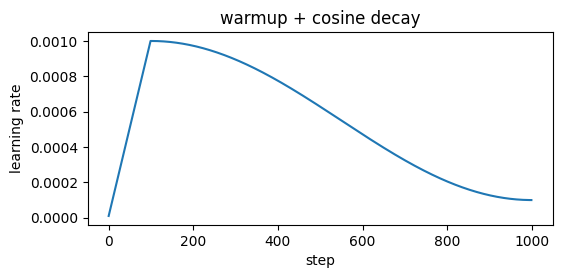

✅ TODO 8 passed


In [24]:
# Test for TODO 8
args = dict(max_lr=1e-3, min_lr=1e-4, warmup_steps=100, max_steps=1000)
check(abs(get_lr(0, **args) - 1e-5) < 1e-12, "warmup: step 0 should give max_lr * 1/100.")
check(abs(get_lr(49, **args) - 5e-4) < 1e-12, "warmup: step 49 should give max_lr * 50/100.")
check(abs(get_lr(100, **args) - 1e-3) < 1e-12, "the learning rate should be max_lr right after warmup.")
check(abs(get_lr(550, **args) - 5.5e-4) < 1e-12, "halfway through the decay the learning rate should be (max_lr + min_lr) / 2.")
check(abs(get_lr(999, **args) - 1e-4) < 1e-8, "at the end the learning rate should approach min_lr.")
steps = list(range(1000))
plt.figure(figsize=(6, 2.5))
plt.plot(steps, [get_lr(s, **args) for s in steps])
plt.xlabel("step"); plt.ylabel("learning rate"); plt.title("warmup + cosine decay"); plt.show()
print("✅ TODO 8 passed")

## 5.2 Measuring progress and counting compute

The next cell has two provided tools:

- `estimate_loss` averages the loss over a few random batches from the training and the validation set. The **training loss** tells us whether the model is learning. The **validation loss** tells us whether it *generalizes* to text it has never seen. If training loss keeps falling while validation loss rises, the model is *overfitting* (memorizing).
- `training_flops` estimates the compute used by a run. Training a transformer costs about **6 floating-point operations (FLOPs) per parameter per token** (2 for the forward pass, 4 for the backward pass), plus a term for attention that grows with the context length (Kaplan et al., 2020):
$$C \approx \left(6N + 12 \cdot n_{\text{layer}} \cdot d \cdot T\right) \times D, \qquad D = \text{steps} \times \text{batch\_size} \times T \ \text{(tokens processed)}$$
where $N$ is the number of parameters. In Part 7 you will work within a fixed budget of $C$.

In [25]:
# 🔒 Do not modify
FLOP_BUDGET = 2e14  # compute budget for Part 7
MAX_BLOCK_SIZE = 512


def training_flops(config, n_params, max_steps, batch_size):
    tokens = max_steps * batch_size * config.block_size
    per_token = 6 * n_params + 12 * config.n_layer * config.n_embd * config.block_size
    return per_token * tokens


@torch.no_grad()
def estimate_loss(model, batch_size, eval_iters=20):
    """Average loss over `eval_iters` random batches of each split."""
    model.eval()  # turns dropout off
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for i in range(eval_iters):
            x, y = get_batch(split, batch_size, model.config.block_size)
            losses[i] = model(x, y)[1].item()
        out[split] = losses.mean().item()
    model.train()  # dropout back on
    return out

## 5.3 The training loop

nanoGPT keeps training settings in a second config. Most fields are the ones explained above. `eval_interval` says how often to measure the losses.

### TODO 9 · one training step (5 points)

Fill in the four lines of a training step: forward pass, clear the old gradients, backward pass, optimizer update. Everything else (schedule, clipping, logging, timing) is provided. **Note:** PyTorch *adds* new gradients to the existing ones, so you must clear them with `optimizer.zero_grad(set_to_none=True)` at every step, before `loss.backward()`.

In [26]:
# TODO 9 is inside train() below: the four lines of "one training step"
@dataclass
class TrainConfig:
    batch_size: int = 32
    max_steps: int = 3000
    learning_rate: float = 3e-3  # max_lr
    min_lr: float = 3e-4         # usually learning_rate / 10
    warmup_steps: int = 100
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    eval_interval: int = 250
    eval_iters: int = 20


def configure_optimizer(model, tc):
    """AdamW; as in GPT-2, weight decay applies to weight matrices and embeddings, not to biases and LayerNorm."""
    decay = [p for p in model.parameters() if p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.dim() < 2]
    groups = [{"params": decay, "weight_decay": tc.weight_decay}, {"params": no_decay, "weight_decay": 0.0}]
    return torch.optim.AdamW(groups, lr=tc.learning_rate, betas=(0.9, 0.99))


RUN_LOG = []  # every call to train() adds one entry, used in Part 7


def train(config, tc, seed=1337, name=None, check_budget=True):
    """Build a fresh GPT from `config` and train it with the settings in `tc`. Returns (model, history)."""
    torch.manual_seed(seed)
    assert config.block_size <= MAX_BLOCK_SIZE, f"block_size must be <= {MAX_BLOCK_SIZE}"
    model = GPT(config).to(device)
    flops = training_flops(config, model.num_params(), tc.max_steps, tc.batch_size)
    print(f"model: {model.num_params():,} parameters | compute: {flops:.2e} FLOPs "
          f"({flops / FLOP_BUDGET:.0%} of the Part 7 budget)")
    if check_budget and flops > FLOP_BUDGET:
        raise ValueError("This run exceeds FLOP_BUDGET. Use fewer steps, a smaller batch or a smaller model.")

    optimizer = configure_optimizer(model, tc)
    history = {"step": [], "train": [], "val": []}
    t0 = time.time()
    for step in range(tc.max_steps + 1):
        # set this step's learning rate
        lr = get_lr(step, tc.learning_rate, tc.min_lr, tc.warmup_steps, tc.max_steps)
        for group in optimizer.param_groups:
            group["lr"] = lr

        # measure progress every eval_interval steps and at the end
        if step % tc.eval_interval == 0 or step == tc.max_steps:
            losses = estimate_loss(model, tc.batch_size, tc.eval_iters)
            history["step"].append(step); history["train"].append(losses["train"]); history["val"].append(losses["val"])
            print(f"step {step:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} "
                  f"| lr {lr:.2e} | {time.time() - t0:6.1f}s")
        if step == tc.max_steps:
            break

        # one training step
        xb, yb = get_batch("train", tc.batch_size, config.block_size)
        logits, loss = model(xb, yb)                    # forward pass
        optimizer.zero_grad(set_to_none=True)           # clear old gradients
        loss.backward()                                 # backward pass, computes the gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), tc.grad_clip)
        optimizer.step()                                # update the parameters

    elapsed = time.time() - t0
    model.run_record = {"name": name or f"run {len(RUN_LOG) + 1}", **asdict(config), **asdict(tc),
                        "params": model.num_params(), "flops": flops, "minutes": elapsed / 60,
                        "train_loss": history["train"][-1], "val_loss": history["val"][-1]}
    RUN_LOG.append(model.run_record)
    print(f"done in {elapsed / 60:.1f} min")
    return model, history


def plot_history(history, title=""):
    plt.figure(figsize=(6, 3.5))
    plt.plot(history["step"], history["train"], label="train")
    plt.plot(history["step"], history["val"], label="val")
    plt.axhline(math.log(vocab_size), color="gray", ls=":", label="uniform guess ln|V|")
    plt.xlabel("step"); plt.ylabel("cross-entropy loss (nats / char)"); plt.title(title)
    plt.ylim(0.6, 4.8); plt.legend(); plt.grid(alpha=0.3); plt.show()

**Smoke test first.** Before a long run, always run a short one. If there is a bug, you find out in seconds instead of minutes. With 200 steps, the loss should fall from about 4.6 to below 2.5.

In [27]:
# Test for TODO 9 (smoke test, about 5-60 seconds)
_, smoke = train(GPTConfig(), TrainConfig(max_steps=200, eval_interval=100, eval_iters=5), name="smoke test")
check(smoke["train"][-1] < 2.5, f"after 200 steps the training loss should be below 2.5, got {smoke['train'][-1]:.2f}. Check your training step.")
RUN_LOG.clear()
print("✅ TODO 9 passed")

model: 822,016 parameters | compute: 4.68e+12 FLOPs (2% of the Part 7 budget)
step     0 | train loss 4.6098 | val loss 4.6075 | lr 3.00e-05 |    0.1s
step   100 | train loss 2.2907 | val loss 2.3023 | lr 3.00e-03 |    2.2s
step   200 | train loss 1.9922 | val loss 2.0291 | lr 3.00e-04 |    3.7s
done in 0.1 min
✅ TODO 9 passed


## 5.4 Train the default model (10 points: validation loss ≤ 1.00)

Now the real run: the default model (0.82 M parameters) for 3,000 steps, which is about 12 million characters, or 30% of our training text. Expected time: about 1–2 minutes on a Colab T4 GPU, 2–15 minutes on a laptop.

While it trains, watch the numbers. The loss starts at ≈ 4.56. It quickly drops to ≈ 2.5 as the model learns which characters are common, and later below 1.0 as it learns words and grammar.

model: 822,016 parameters | compute: 7.03e+13 FLOPs (35% of the Part 7 budget)
step     0 | train loss 4.6080 | val loss 4.6081 | lr 3.00e-05 |    0.2s
step   250 | train loss 1.8593 | val loss 1.8518 | lr 2.98e-03 |    4.1s
step   500 | train loss 1.4268 | val loss 1.4150 | lr 2.88e-03 |    8.1s
step   750 | train loss 1.2486 | val loss 1.2304 | lr 2.68e-03 |   12.3s
step  1000 | train loss 1.1386 | val loss 1.1515 | lr 2.41e-03 |   16.2s
step  1250 | train loss 1.0712 | val loss 1.0679 | lr 2.08e-03 |   20.2s
step  1500 | train loss 1.0189 | val loss 1.0246 | lr 1.72e-03 |   24.4s
step  1750 | train loss 0.9774 | val loss 0.9904 | lr 1.36e-03 |   28.4s
step  2000 | train loss 0.9477 | val loss 0.9306 | lr 1.02e-03 |   32.5s
step  2250 | train loss 0.9079 | val loss 0.9141 | lr 7.22e-04 |   36.8s
step  2500 | train loss 0.8802 | val loss 0.8780 | lr 4.93e-04 |   40.9s
step  2750 | train loss 0.8756 | val loss 0.8711 | lr 3.49e-04 |   45.0s
step  3000 | train loss 0.8687 | val loss 0.8

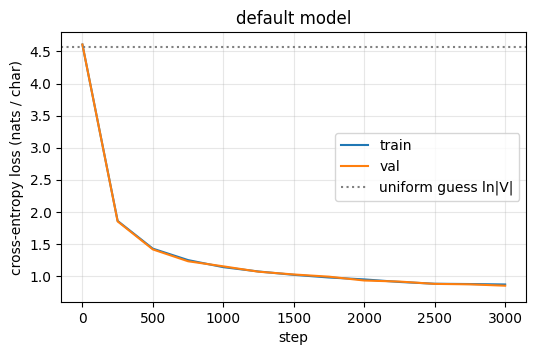

In [28]:
default_config = GPTConfig()
default_train = TrainConfig()
model, history = train(default_config, default_train, name="default")
plot_history(history, "default model")
torch.save(model.state_dict(), "gpt_default.pt")  # keep a copy in case the runtime restarts

### ➕ Extra: the default model in three units

The default model must reach a validation loss of at most 1.00. `estimate_loss` samples random batches, so its value changes a little from run to run (standard error about 0.003-0.004). The fixed-slice number below is **deterministic**: it is the first 1,000,000 validation characters cut into consecutive windows, the same slice the Part 8 evaluation uses. We define the helper here and reuse it for every comparison later.

In [29]:
# ➕ Extra: deterministic evaluation on the same fixed slice as the Part 8 evaluation (our own helper; Part 8 itself is untouched)
@torch.no_grad()
def fixed_slice_losses(m, n_chars=1_000_000, batch_size=32):
    """Mean loss of every window of the fixed validation slice, shape (n_windows,)."""
    m.eval()
    T = m.config.block_size
    n_windows = n_chars // T
    data = val_data[: n_windows * T + 1].long()
    x_all, y_all = data[:-1].view(n_windows, T), data[1:].view(n_windows, T)
    out = []
    for i in range(0, n_windows, batch_size):
        x, y = x_all[i : i + batch_size].to(device), y_all[i : i + batch_size].to(device)
        logits, _ = m(x)
        per_token = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="none")
        out.append(per_token.view(x.size(0), T).mean(dim=1).cpu())
    m.train()
    return torch.cat(out)


def fixed_slice_loss(m):
    return fixed_slice_losses(m).mean().item()


d_loss = fixed_slice_loss(model)
print(f"default model, fixed validation slice: {d_loss:.4f} nats/char "
      f"| perplexity {math.exp(d_loss):.2f} | {d_loss / math.log(2):.3f} bits/char "
      f"| compression vs. 8-bit ASCII: {8 / (d_loss / math.log(2)):.1f}x")
print(f"requirement (<= 1.00): {'PASSED' if d_loss <= 1.00 else 'NOT MET'}")
print(f"baselines: uniform {baselines['uniform']:.3f} | unigram {baselines['unigram']:.3f} | bigram {baselines['bigram']:.3f}")

default model, fixed validation slice: 0.8585 nats/char | perplexity 2.36 | 1.239 bits/char | compression vs. 8-bit ASCII: 6.5x
requirement (<= 1.00): PASSED
baselines: uniform 4.564 | unigram 3.081 | bigram 2.280


### What does the loss mean?

A loss of $\mathcal{L}$ nats per character can be read in two more intuitive ways:

- **Perplexity** $= e^{\mathcal{L}}$: the model is, on average, as uncertain as if it were choosing uniformly among $e^{\mathcal{L}}$ characters. At the start, $e^{4.56} = 96$ (all characters equally likely). At $\mathcal{L} = 1.0$ it is $e^1 \approx 2.7$ characters.
- **Bits per character** $= \mathcal{L} / \ln 2$: how many bits an ideal compressor built on this model would need per character. Plain ASCII uses 8 bits per character. A model at 1.0 nats/char ≈ 1.44 bits/char compresses these stories more than 5×. **Language modeling is compression.**

---
# Part 6 · Generating text

The model outputs a probability distribution over the next character. To generate, we repeat these steps:

1. feed the current sequence (at most the last `block_size` tokens, because the position table has only `block_size` rows),
2. take the logits $z$ at the **last** position only, the prediction for the next token,
3. divide by the **temperature** $\tau$ and apply softmax: $p_i = \dfrac{e^{z_i/\tau}}{\sum_j e^{z_j/\tau}}$,
4. **sample** the next token from $p$ and append it to the sequence.

**Temperature** controls randomness. $\tau < 1$ sharpens the distribution (safer, more repetitive text); as $\tau \to 0$ we always pick the most likely token ("greedy" decoding). $\tau > 1$ flattens it (more surprising text, more mistakes). **Top-$k$ sampling** additionally keeps only the $k$ most likely tokens and sets all other logits to $-\infty$ before the softmax, so very unlikely tokens are never picked.

### TODO 10 · `generate` (5 points)

Useful: `idx[:, -n:]` keeps the last `n` columns; `logits[:, -1, :]` selects the last position; `torch.multinomial(probs, num_samples=1)` samples one index per row, with shape `(B, 1)`; `torch.cat((a, b), dim=1)` appends along the time dimension.

In [30]:
# TODO 10
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    """
    idx: (B, T) tensor of token ids (the prompt).
    Returns a (B, T + max_new_tokens) tensor: the prompt followed by the sampled tokens.
    """
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.block_size:]  # crop to the last block_size tokens
        logits, _ = model(idx_cond)                  # (B, T, vocab_size)
        logits = logits[:, -1, :] / temperature  # (B, vocab_size)
        if top_k is not None:
            kth_largest = torch.topk(logits, min(top_k, logits.size(-1))).values[:, [-1]]
            logits = logits.masked_fill(logits < kth_largest, float("-inf"))
        probs = F.softmax(logits, dim=-1)  # (B, vocab_size)
        idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
        idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)
    model.train()
    return idx


def complete(prompt, max_new_tokens=500, temperature=0.8, top_k=None, model_=None):
    """Convenience wrapper: string in, string out."""
    m = model_ if model_ is not None else model
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    return decode(generate(m, idx, max_new_tokens, temperature, top_k)[0].tolist())

In [31]:
# Test for TODO 10
torch.manual_seed(0)
prompt = torch.tensor([encode("Once upon a time")], device=device)
out = generate(model, prompt, 20)
check(isinstance(out, torch.Tensor) and tuple(out.shape) == (1, 16 + 20), f"output should have shape (1, 36), got {getattr(out, 'shape', None)}.")
check(torch.equal(out[:, :16], prompt), "the output should start with the prompt.")
long_prompt = torch.randint(vocab_size, (2, model.config.block_size + 10), device=device)
check(generate(model, long_prompt, 3).shape == (2, model.config.block_size + 13), "prompts longer than block_size should be cropped, not rejected.")
greedy = prompt.clone()
for _ in range(20):
    greedy = torch.cat((greedy, model(greedy)[0][:, -1].argmax(-1, keepdim=True)), dim=1)
check(torch.equal(generate(model, prompt, 20, top_k=1), greedy), "with top_k=1 the output should be the greedy (argmax) continuation.")
check(torch.equal(generate(model, prompt, 20, temperature=1e-3), greedy), "with a tiny temperature the output should be the greedy (argmax) continuation.")
print("✅ TODO 10 passed")

✅ TODO 10 passed


Let's read what the model writes. Try your own prompts!

In [32]:
torch.manual_seed(42)
print(complete("Once upon a time", temperature=0.8))

Once upon a time, there was a real jar named Sam. Sam lived in a thick. Tom was a happy to the marble. They were very excited and had lots of fun. Tom was very happy and thanked the toy box. They played together and had a great time.
<|endoftext|>
Once upon a time, there was a little boy named Tim. Tim liked to play with his toy car. It was a sad bucky hand and made him. He said not come special eyes. Tim was happy and said, "That is safe and sharing with that being better."
Mia and Ben learned that they acceam


In [33]:
torch.manual_seed(0)
for temperature in [0.5, 1.0, 1.5]:
    print(f"========== temperature {temperature} ==========")
    print(complete("One day, a little dog", max_new_tokens=300, temperature=temperature))
    print()

========== temperature 0.5 ==========
One day, a little dog named Max had a big street. Max was very happy and said, "Why are you sad?" The bird cried, "I love to play with it. Can I have a new friend." The picture was so happy to have a big friend.
As they played, the bird saw a big smile on the sky. The fancy was happy too. The squirrel was very happy. Th

========== temperature 1.0 ==========
One day, a little dog named Spot found a tree. The whale had red bandy with a book tires and made some good food for balloon. He also laughed and happy to read his friends to help. The big side and the airor.
While Miama loused her pebbles owl and yummy twing. She played with it, but it was too high for a happy.
<|endof

========== temperature 1.5 ==========
One day, a little dog met a street broes on i land. <|endoftext|>
Lily realing the filthy re lived happy. The olderful played dtJimb, she saw An us folds that, so she brighed balancel. She ran allowed her, behy and he gave her a fruit. Ecte

### ✍️ Q4 (2 points)
Compare the samples at temperatures 0.5, 1.0 and 1.5. Describe the differences in spelling, grammar and repetition, and explain them with the formula $p_i = e^{z_i/\tau} / \sum_j e^{z_j/\tau}$.

*Your answer:*

The three samples come from the same model; only the temperature $\tau$ in $p_i = e^{z_i/\tau}/\sum_j e^{z_j/\tau}$ changes.

- **$\tau = 0.5$.** Dividing the logits by a small number *stretches* the gaps between them, so the softmax puts most of its probability on the likeliest character. This is the cleanest sample: every word is a real word, there are quotation marks and questions, and the sentences are short and mostly grammatical ("One day, a little dog named Max had a big street. Max was very happy and said, "Why are you sad?""), although the meaning drifts ("a big street", "The picture was so happy"). The price is diversity: "happy" appears four times in a few sentences ("very happy", "so happy", "was happy too", "very happy") and "a big" returns ("a big street", "a big friend", "a big smile").
- **$\tau = 1.0$.** We sample from the distribution the model actually learned. Names and sentence shapes are plausible ("One day, a little dog named Spot found a tree."), but non-words appear ("airor", "Miama", "loused", "twing") and the grammar breaks ("He also laughed and happy to read his friends to help", "made some good food for balloon"). The sample also ends with the start of the end-of-text marker `<|endof...`: the model learned from the data that stories end.
- **$\tau = 1.5$.** Dividing by a number larger than 1 *flattens* the distribution, so unlikely characters get a real share of the probability. Non-words are everywhere ("broes", "realing", "olderful", "brighed", "balancel", "Ectefully", "shouthed"), capital letters land inside words ("dtJimb"), punctuation lands in odd places ("together: shouthed", "blends!"), and the story is even cut after one sentence by an `<|endoftext|>` marker. Because each character is sampled given the previous ones, one bad character pushes the context away from the training data, the next prediction gets worse, and the errors compound.

As $\tau\to0$ the output becomes greedy decoding (always the argmax); as $\tau\to\infty$ it approaches uniform noise over the 96 characters.

---
# Part 7 · Beat the target under a compute budget

Your default model should be at or below 1.00. Now make it as good as you can. **The rule:** each training run may use at most **`FLOP_BUDGET` = 2 × 10¹⁴ FLOPs**, measured by `training_flops` (the default run uses about 35% of it), and `block_size` ≤ 512. This budget is the same for everyone, whatever your hardware. A GPU just gets there faster. A full-budget run takes about 3–6 minutes on a Colab T4 and roughly 10–40 minutes on a laptop CPU.

### Score (20 points), measured by the 🔒 final evaluation in Part 8

| Final validation loss | ≤ 0.85 | ≤ 0.80 | ≤ 0.76 | ≤ 0.74 | ≤ 0.725 |
|---|---|---|---|---|---|
| Points | 8 | 12 | 16 | 18 | 20 |

A model that is over the budget, or was not trained with `train()`, gets 0 points for the score. The top tier is reachable with this notebook's model on the free hardware; it takes a few well-chosen experiments, not a bigger computer.

### Which knobs to try

| Knob | What it changes | Things to think about |
|---|---|---|
| `max_steps` | how many tokens the model sees | The default uses only ~35% of the budget. |
| `n_embd`, `n_layer`, `n_head` | model size $N$ | A bigger model learns more per token, but each token costs more. `n_embd` must be divisible by `n_head`. |
| `block_size` | context length $T$ | More context helps predict the next character. Attention cost grows with $T$. |
| `batch_size` | tokens per step | Larger batches give less noisy gradients, but fewer steps fit in the budget. |
| `learning_rate` (and `min_lr`) | step size | Bigger models usually need a **smaller** learning rate, e.g. 1e-3 to 2e-3. If the loss jumps up or becomes `nan`, lower it. |
| `dropout` | regularization | Only useful if the validation loss is clearly worse than the training loss (overfitting). |
| `TRAIN_MB` (Part 1) | amount of training data | Only matters if you pass over the same text many times. Re-run from the top after changing it. |

**For a fixed compute budget $C \approx 6ND$, there is a trade-off between model size $N$ and training tokens $D$.** A huge model trained on a few tokens and a tiny model trained on many tokens are both bad. The best choice lies in between (Hoffmann et al., 2022, the "Chinchilla" paper). Finding it is exactly what the teams that train large language models do, only with a much larger $C$.

**Work efficiently.** Use short runs (for example ¼ of the budget) to compare settings, then spend the full budget on your best one. Every call to `train` is recorded in `RUN_LOG`, and `show_runs()` prints the table.

In [34]:
def show_runs():
    cols = ["name", "n_layer", "n_embd", "n_head", "block_size", "batch_size", "max_steps", "learning_rate",
            "dropout", "params", "flops", "minutes", "train_loss", "val_loss"]
    print(" | ".join(f"{c:>13s}" if c != "name" else f"{c:16s}" for c in cols))
    for r in RUN_LOG:
        cells = []
        for c in cols:
            v = r[c]
            if c == "name": cells.append(f"{str(v)[:16]:16s}")
            elif c in ("flops", "learning_rate"): cells.append(f"{v:13.1e}")
            elif isinstance(v, float): cells.append(f"{v:13.3f}")
            else: cells.append(f"{v:13,}")
        print(" | ".join(cells))


show_runs()

name             |       n_layer |        n_embd |        n_head |    block_size |    batch_size |     max_steps | learning_rate |       dropout |        params |         flops |       minutes |    train_loss |      val_loss
default          |             4 |           128 |             4 |           128 |            32 |         3,000 |       3.0e-03 |         0.000 |       822,016 |       7.0e+13 |         0.822 |         0.869 |         0.849


### 7.1 ➕ Tooling for a careful search

Short runs are cheap but noisy, and **short-run rankings do not always carry over to the full budget** (a model that is ahead after 10% of the compute can fall behind after 100%). Three habits make the search trustworthy:

1. **Budget planner.** Every candidate is converted into a number of steps with `steps_for_fraction`, which uses the same formula as the 🔒 `training_flops`, so no run can exceed `FLOP_BUDGET` by accident.
2. **Deterministic comparison.** Candidates are ranked with `fixed_slice_loss` (defined in Part 5), not with the noisy `estimate_loss`.
3. **A margin of safety.** We only leave the baseline configuration if another one beats it by more than `MARGIN`, which is larger than the remaining noise. A tiny "win" in one short run is not evidence.

In [35]:
# ➕ Extra: budget planner
SCREEN_FRACTION = 0.12   # each screening run uses 12% of FLOP_BUDGET
FINAL_FRACTION = 0.995   # the final run uses 99.5% of FLOP_BUDGET (a small safety margin)
MARGIN = 0.010           # a candidate must beat the baseline by more than this to be chosen


def flops_per_step(config, batch_size):
    return training_flops(config, GPT(config).num_params(), 1, batch_size)


def steps_for_fraction(config, batch_size, fraction):
    return int(fraction * FLOP_BUDGET // flops_per_step(config, batch_size))


candidates = {
    # name: (model config, training settings)
    "base lr3e-3": (GPTConfig(),                 dict(batch_size=32, learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "lr 2e-3":     (GPTConfig(),                 dict(batch_size=32, learning_rate=2e-3, min_lr=2e-4, weight_decay=0.1)),
    "context 256": (GPTConfig(block_size=256),   dict(batch_size=16, learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "wd 0.01":     (GPTConfig(),                 dict(batch_size=32, learning_rate=3e-3, min_lr=3e-4, weight_decay=0.01)),
}

print(f"{'candidate':14s} {'params':>9s} {'tokens/step':>12s} {'screen steps':>13s} {'final steps':>12s} {'final FLOPs':>12s}")
for name, (cfg, kw) in candidates.items():
    n = GPT(cfg).num_params()
    s_scr = steps_for_fraction(cfg, kw["batch_size"], SCREEN_FRACTION)
    s_fin = steps_for_fraction(cfg, kw["batch_size"], FINAL_FRACTION)
    f_fin = training_flops(cfg, n, s_fin, kw["batch_size"])
    assert f_fin <= FLOP_BUDGET
    print(f"{name:14s} {n:9,d} {kw['batch_size'] * cfg.block_size:12,d} {s_scr:13,d} {s_fin:12,d} {f_fin:12.3e}")

candidate         params  tokens/step  screen steps  final steps  final FLOPs
base lr3e-3      822,016        4,096         1,024        8,495    1.990e+14
lr 2e-3          822,016        4,096         1,024        8,495    1.990e+14
context 256      838,400        4,096           887        7,357    1.990e+14
wd 0.01          822,016        4,096         1,024        8,495    1.990e+14


### 7.2 ➕ Screening runs

Each candidate trains for 12% of the budget with its own setting, then is scored on the fixed slice. The four runs are independent, so you can run them one cell at a time. Each run is recorded in `RUN_LOG` and so appears in the table of `show_runs()`.

In [36]:
SCREEN = {}   # candidate name -> fixed-slice validation loss after its screening run


def run_candidate(name):
    cfg, kw = candidates[name]
    steps = steps_for_fraction(cfg, kw["batch_size"], SCREEN_FRACTION)
    tc = TrainConfig(max_steps=steps, warmup_steps=min(100, steps // 10), eval_interval=max(1, steps // 4), eval_iters=20, **kw)
    m, h = train(cfg, tc, name="screen: " + name)
    SCREEN[name] = fixed_slice_loss(m)
    print(f"-> {name}: fixed-slice validation loss {SCREEN[name]:.4f}")
    return h

In [37]:
h_base = run_candidate("base lr3e-3")

model: 822,016 parameters | compute: 2.40e+13 FLOPs (12% of the Part 7 budget)
step     0 | train loss 4.6080 | val loss 4.6081 | lr 3.00e-05 |    0.3s
step   256 | train loss 1.8446 | val loss 1.8458 | lr 2.81e-03 |    4.7s
step   512 | train loss 1.3950 | val loss 1.3792 | lr 1.88e-03 |    9.0s
step   768 | train loss 1.1981 | val loss 1.1891 | lr 7.80e-04 |   13.2s
step  1024 | train loss 1.0986 | val loss 1.0926 | lr 3.00e-04 |   17.6s
done in 0.3 min
-> base lr3e-3: fixed-slice validation loss 1.1050


In [38]:
h_lr2 = run_candidate("lr 2e-3")

model: 822,016 parameters | compute: 2.40e+13 FLOPs (12% of the Part 7 budget)
step     0 | train loss 4.6080 | val loss 4.6081 | lr 2.00e-05 |    0.2s
step   256 | train loss 1.8992 | val loss 1.8997 | lr 1.88e-03 |    4.5s
step   512 | train loss 1.4480 | val loss 1.4275 | lr 1.25e-03 |    9.7s
step   768 | train loss 1.2514 | val loss 1.2413 | lr 5.20e-04 |   13.9s
step  1024 | train loss 1.1437 | val loss 1.1367 | lr 2.00e-04 |   18.1s
done in 0.3 min
-> lr 2e-3: fixed-slice validation loss 1.1527


In [39]:
h_ctx = run_candidate("context 256")

model: 838,400 parameters | compute: 2.40e+13 FLOPs (12% of the Part 7 budget)
step     0 | train loss 4.6084 | val loss 4.6084 | lr 3.41e-05 |    0.3s
step   221 | train loss 2.1933 | val loss 2.1770 | lr 2.82e-03 |    5.0s
step   442 | train loss 1.7279 | val loss 1.7164 | lr 1.89e-03 |    9.6s
step   663 | train loss 1.4184 | val loss 1.4053 | lr 7.91e-04 |   14.2s
step   884 | train loss 1.2926 | val loss 1.2828 | lr 3.00e-04 |   18.8s
step   887 | train loss 1.2962 | val loss 1.3024 | lr 3.00e-04 |   19.2s
done in 0.3 min
-> context 256: fixed-slice validation loss 1.2821


In [40]:
h_wd = run_candidate("wd 0.01")

model: 822,016 parameters | compute: 2.40e+13 FLOPs (12% of the Part 7 budget)
step     0 | train loss 4.6080 | val loss 4.6081 | lr 3.00e-05 |    0.2s
step   256 | train loss 1.8177 | val loss 1.8207 | lr 2.81e-03 |    4.4s
step   512 | train loss 1.3995 | val loss 1.3814 | lr 1.88e-03 |    8.8s
step   768 | train loss 1.1907 | val loss 1.1840 | lr 7.80e-04 |   12.9s
step  1024 | train loss 1.0892 | val loss 1.0842 | lr 3.00e-04 |   17.1s
done in 0.3 min
-> wd 0.01: fixed-slice validation loss 1.0979


### 7.3 ➕ Choose the configuration

The rule is fixed **before** looking at the numbers: take the baseline unless another candidate is better by more than `MARGIN`; among those take the best one.

candidate       fixed-slice val loss   vs base
wd 0.01                       1.0979   -0.0070
base lr3e-3                   1.1050   +0.0000
lr 2e-3                       1.1527   +0.0478
context 256                   1.2821   +0.1772

chosen configuration for the full-budget run: 'base lr3e-3'  (no candidate beat the baseline by more than the margin)


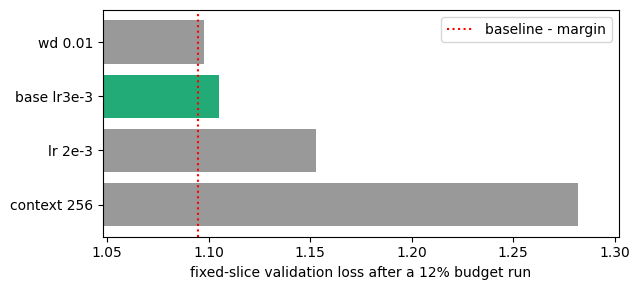

In [41]:
base_name = "base lr3e-3"
ranked = sorted(SCREEN.items(), key=lambda kv: kv[1])
print(f"{'candidate':14s} {'fixed-slice val loss':>21s} {'vs base':>9s}")
for name, v in ranked:
    print(f"{name:14s} {v:21.4f} {v - SCREEN[base_name]:+9.4f}")

better = {n: v for n, v in SCREEN.items() if n != base_name and v < SCREEN[base_name] - MARGIN}
chosen = min(better, key=better.get) if better else base_name
print(f"\nchosen configuration for the full-budget run: '{chosen}'"
      + ("" if better else "  (no candidate beat the baseline by more than the margin)"))

plt.figure(figsize=(6.5, 3))
names = [n for n, _ in ranked]
plt.barh(names[::-1], [v for _, v in ranked][::-1], color=["#2a7" if n == chosen else "#999" for n in names[::-1]])
plt.axvline(SCREEN[base_name] - MARGIN, color="r", ls=":", label="baseline - margin")
plt.xlim(min(SCREEN.values()) - 0.05, max(SCREEN.values()) + 0.02)
plt.xlabel("fixed-slice validation loss after a 12% budget run"); plt.legend(); plt.tight_layout(); plt.show()

### 7.4 ➕ Full-budget runs: is a longer context worth its cost?

A screening run uses only 12% of the budget, and short runs can mislead (see 7.1). On a T4 a full-budget run takes only a few minutes, so the final comparison uses the **full budget** (99.5% of `FLOP_BUDGET`) for every setting. The settings differ in the knobs that Part 7 lists as `block_size`, `batch_size` and `learning_rate`:

* The 🔒 Part 8 evaluation cuts the validation slice into consecutive windows of the model's own `block_size`. The first characters of a window have almost no context and are the hardest to predict (see the loss-by-position plot after Part 8). With a longer `block_size`, a smaller share of the scored characters sits at the start of a window, so the measured loss falls. Part of an improvement from a longer context is therefore due to how Part 8 scores, and the rest to the model really using more context or to other changes that come with it. Appendix B measures the split: the window length explains the whole difference between the two models.
* A longer context costs more FLOPs per token (the attention term grows with $T$), so at a fixed budget fewer tokens are seen. The batch size is lowered with $T$ so that the tokens per step stay between 2,048 and 4,096 (the baseline has 4,096). `T256 bs8` has 2,048 tokens per step and therefore about twice as many steps as `T256 bs16`.

**Rule, fixed before the runs:** the final model is the setting with the lowest fixed-slice loss (seed 1337). Afterwards the winner and the baseline are trained with two fresh seeds, so that a gain that is only luck would show up. Every model is trained by `train()`, in fp32, within `FLOP_BUDGET`.

In [42]:
FULL_PLAN = {
    # name: (model config, training settings)   min_lr = learning_rate / 10, weight decay 0.1 everywhere
    "T128 bs32 (baseline)": (GPTConfig(block_size=128), dict(batch_size=32, learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "T256 bs16":            (GPTConfig(block_size=256), dict(batch_size=16, learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "T256 bs8":             (GPTConfig(block_size=256), dict(batch_size=8,  learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "T256 bs16 lr4e-3":     (GPTConfig(block_size=256), dict(batch_size=16, learning_rate=4e-3, min_lr=4e-4, weight_decay=0.1)),
    "T384 bs8":             (GPTConfig(block_size=384), dict(batch_size=8,  learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
    "T512 bs8":             (GPTConfig(block_size=512), dict(batch_size=8,  learning_rate=3e-3, min_lr=3e-4, weight_decay=0.1)),
}
BASE_FULL = "T128 bs32 (baseline)"
FULL_LOSS, FULL_MODELS, FULL_TC, FULL_HIST = {}, {}, {}, {}


def full_training_config(name, steps=None):
    cfg_, kw_ = FULL_PLAN[name]
    steps = steps_for_fraction(cfg_, kw_["batch_size"], FINAL_FRACTION) if steps is None else steps
    return TrainConfig(max_steps=steps, warmup_steps=200, eval_interval=500, eval_iters=20, **kw_)


def run_full(name):
    cfg_, _ = FULL_PLAN[name]
    tc_ = full_training_config(name)
    m_, h_ = train(cfg_, tc_, name="full: " + name)
    FULL_LOSS[name], FULL_MODELS[name], FULL_TC[name], FULL_HIST[name] = fixed_slice_loss(m_), m_, tc_, h_
    plot_history(h_, "full budget: " + name)
    print(f"-> {name}: fixed-slice validation loss {FULL_LOSS[name]:.4f}")


print(f"{'setting':22s} {'T':>4s} {'batch':>6s} {'steps':>7s} {'tokens/step':>12s} {'params':>9s} {'FLOPs':>11s}")
for name_, (cfg_, kw_) in FULL_PLAN.items():
    n_ = GPT(cfg_).num_params(); s_ = steps_for_fraction(cfg_, kw_["batch_size"], FINAL_FRACTION)
    f_ = training_flops(cfg_, n_, s_, kw_["batch_size"]); assert f_ <= FLOP_BUDGET
    print(f"{name_:22s} {cfg_.block_size:4d} {kw_['batch_size']:6d} {s_:7,d} {kw_['batch_size'] * cfg_.block_size:12,d} {n_:9,d} {f_:11.3e}")

setting                   T  batch   steps  tokens/step    params       FLOPs
T128 bs32 (baseline)    128     32   8,495        4,096   822,016   1.990e+14
T256 bs16               256     16   7,357        4,096   838,400   1.990e+14
T256 bs8                256      8  14,715        2,048   838,400   1.990e+14
T256 bs16 lr4e-3        256     16   7,357        4,096   838,400   1.990e+14
T384 bs8                384      8   8,650        3,072   854,784   1.990e+14
T512 bs8                512      8   5,802        4,096   871,168   1.990e+14


model: 822,016 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6080 | val loss 4.6081 | lr 1.50e-05 |    0.2s
step   500 | train loss 1.4382 | val loss 1.4447 | lr 2.99e-03 |    8.2s
step  1000 | train loss 1.1544 | val loss 1.1542 | lr 2.94e-03 |   16.3s
step  1500 | train loss 1.0407 | val loss 1.0179 | lr 2.84e-03 |   24.5s
step  2000 | train loss 0.9853 | val loss 0.9727 | lr 2.70e-03 |   32.5s
step  2500 | train loss 0.9516 | val loss 0.9555 | lr 2.52e-03 |   40.7s
step  3000 | train loss 0.9244 | val loss 0.9295 | lr 2.31e-03 |   48.7s
step  3500 | train loss 0.9106 | val loss 0.9010 | lr 2.08e-03 |   56.8s
step  4000 | train loss 0.8758 | val loss 0.8637 | lr 1.83e-03 |   64.9s
step  4500 | train loss 0.8547 | val loss 0.8472 | lr 1.57e-03 |   72.9s
step  5000 | train loss 0.8255 | val loss 0.8329 | lr 1.32e-03 |   80.9s
step  5500 | train loss 0.8055 | val loss 0.8229 | lr 1.08e-03 |   89.0s
step  6000 | train loss 0.7936 | val loss 0.7

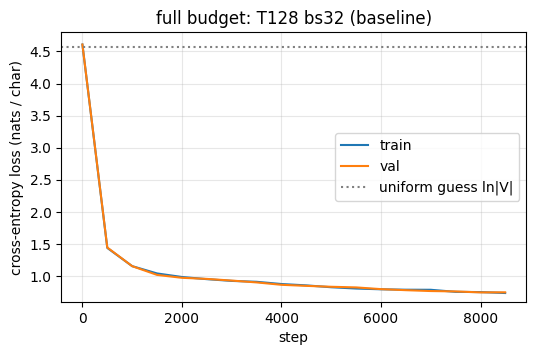

-> T128 bs32 (baseline): fixed-slice validation loss 0.7478


In [43]:
run_full("T128 bs32 (baseline)")

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6084 | val loss 4.6084 | lr 1.50e-05 |    0.3s
step   500 | train loss 1.6983 | val loss 1.6922 | lr 2.99e-03 |   10.5s
step  1000 | train loss 1.2533 | val loss 1.2737 | lr 2.92e-03 |   20.6s
step  1500 | train loss 1.0953 | val loss 1.0867 | lr 2.79e-03 |   30.8s
step  2000 | train loss 1.0076 | val loss 1.0090 | lr 2.60e-03 |   41.0s
step  2500 | train loss 0.9497 | val loss 0.9527 | lr 2.37e-03 |   51.2s
step  3000 | train loss 0.9220 | val loss 0.9101 | lr 2.10e-03 |   61.3s
step  3500 | train loss 0.8669 | val loss 0.8875 | lr 1.81e-03 |   71.5s
step  4000 | train loss 0.8637 | val loss 0.8703 | lr 1.52e-03 |   81.7s
step  4500 | train loss 0.8304 | val loss 0.8244 | lr 1.23e-03 |   91.8s
step  5000 | train loss 0.7921 | val loss 0.7825 | lr 9.60e-04 |  102.0s
step  5500 | train loss 0.7713 | val loss 0.7730 | lr 7.24e-04 |  112.1s
step  6000 | train loss 0.7661 | val loss 0.7

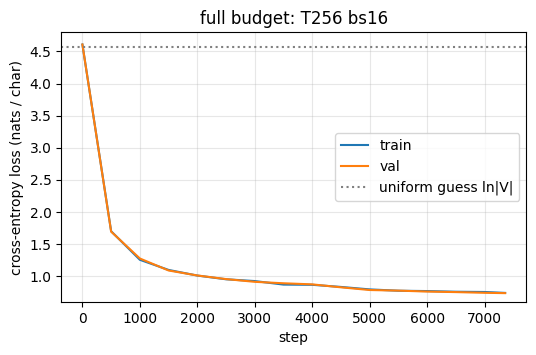

-> T256 bs16: fixed-slice validation loss 0.7343


In [44]:
run_full("T256 bs16")

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6083 | val loss 4.6080 | lr 1.50e-05 |    0.2s
step   500 | train loss 2.0297 | val loss 2.0065 | lr 3.00e-03 |    6.2s
step  1000 | train loss 1.4018 | val loss 1.3707 | lr 2.98e-03 |   12.0s
step  1500 | train loss 1.2318 | val loss 1.2144 | lr 2.95e-03 |   17.7s
step  2000 | train loss 1.1320 | val loss 1.1338 | lr 2.90e-03 |   23.7s
step  2500 | train loss 1.0604 | val loss 1.0818 | lr 2.84e-03 |   29.3s
step  3000 | train loss 1.0460 | val loss 1.0275 | lr 2.76e-03 |   35.5s
step  3500 | train loss 1.0078 | val loss 0.9870 | lr 2.67e-03 |   41.1s
step  4000 | train loss 0.9584 | val loss 0.9608 | lr 2.57e-03 |   47.3s
step  4500 | train loss 0.9182 | val loss 0.9662 | lr 2.46e-03 |   52.9s
step  5000 | train loss 0.9066 | val loss 0.9069 | lr 2.33e-03 |   59.2s
step  5500 | train loss 0.9153 | val loss 0.9113 | lr 2.21e-03 |   64.8s
step  6000 | train loss 0.8856 | val loss 0.8

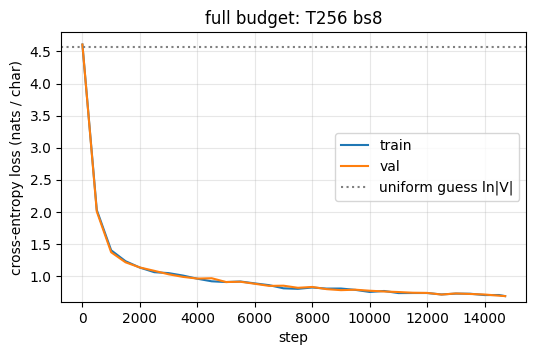

-> T256 bs8: fixed-slice validation loss 0.7016


In [45]:
run_full("T256 bs8")

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6084 | val loss 4.6084 | lr 2.00e-05 |    0.3s
step   500 | train loss 1.6260 | val loss 1.6186 | lr 3.98e-03 |   10.4s
step  1000 | train loss 1.2109 | val loss 1.2274 | lr 3.89e-03 |   20.6s
step  1500 | train loss 1.0634 | val loss 1.0550 | lr 3.71e-03 |   30.7s
step  2000 | train loss 0.9784 | val loss 0.9835 | lr 3.47e-03 |   40.8s
step  2500 | train loss 0.9320 | val loss 0.9309 | lr 3.16e-03 |   51.0s
step  3000 | train loss 0.8878 | val loss 0.8777 | lr 2.80e-03 |   61.1s
step  3500 | train loss 0.8355 | val loss 0.8524 | lr 2.42e-03 |   71.3s
step  4000 | train loss 0.8238 | val loss 0.8364 | lr 2.03e-03 |   81.5s
step  4500 | train loss 0.7995 | val loss 0.7950 | lr 1.64e-03 |   91.7s
step  5000 | train loss 0.7642 | val loss 0.7578 | lr 1.28e-03 |  101.8s
step  5500 | train loss 0.7437 | val loss 0.7491 | lr 9.66e-04 |  112.0s
step  6000 | train loss 0.7380 | val loss 0.7

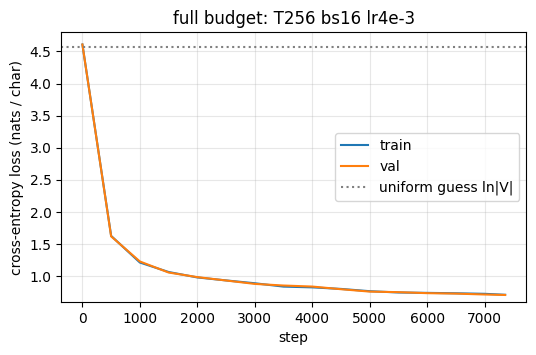

-> T256 bs16 lr4e-3: fixed-slice validation loss 0.7067


In [46]:
run_full("T256 bs16 lr4e-3")

model: 854,784 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5937 | val loss 4.5958 | lr 1.50e-05 |    0.3s
step   500 | train loss 2.1544 | val loss 2.1675 | lr 2.99e-03 |    9.8s
step  1000 | train loss 1.3343 | val loss 1.3368 | lr 2.94e-03 |   19.4s
step  1500 | train loss 1.1997 | val loss 1.2117 | lr 2.85e-03 |   28.9s
step  2000 | train loss 1.1555 | val loss 1.1162 | lr 2.71e-03 |   38.5s
step  2500 | train loss 1.0531 | val loss 1.0624 | lr 2.54e-03 |   48.0s
step  3000 | train loss 0.9831 | val loss 0.9911 | lr 2.33e-03 |   57.6s
step  3500 | train loss 0.9811 | val loss 0.9607 | lr 2.11e-03 |   67.1s
step  4000 | train loss 0.9186 | val loss 0.9249 | lr 1.86e-03 |   76.7s
step  4500 | train loss 0.8627 | val loss 0.8751 | lr 1.61e-03 |   86.2s
step  5000 | train loss 0.8542 | val loss 0.8542 | lr 1.36e-03 |   95.8s
step  5500 | train loss 0.8147 | val loss 0.8292 | lr 1.12e-03 |  105.3s
step  6000 | train loss 0.7770 | val loss 0.8

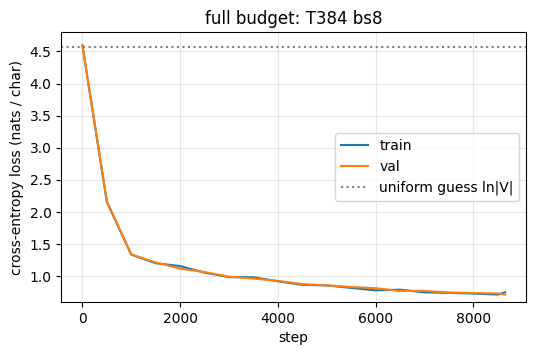

-> T384 bs8: fixed-slice validation loss 0.7211


In [47]:
run_full("T384 bs8")

model: 871,168 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5966 | val loss 4.5994 | lr 1.50e-05 |    0.4s
step   500 | train loss 2.1348 | val loss 2.1234 | lr 2.98e-03 |   14.9s
step  1000 | train loss 1.3951 | val loss 1.4001 | lr 2.87e-03 |   29.5s
step  1500 | train loss 1.1780 | val loss 1.1948 | lr 2.66e-03 |   44.0s
step  2000 | train loss 1.0591 | val loss 1.0366 | lr 2.37e-03 |   58.6s
step  2500 | train loss 0.9667 | val loss 0.9727 | lr 2.02e-03 |   73.1s
step  3000 | train loss 0.9024 | val loss 0.8917 | lr 1.65e-03 |   87.6s
step  3500 | train loss 0.8343 | val loss 0.8244 | lr 1.28e-03 |  102.2s
step  4000 | train loss 0.7980 | val loss 0.8128 | lr 9.33e-04 |  116.8s
step  4500 | train loss 0.7600 | val loss 0.7552 | lr 6.44e-04 |  131.3s
step  5000 | train loss 0.7434 | val loss 0.7668 | lr 4.34e-04 |  145.9s
step  5500 | train loss 0.7099 | val loss 0.7328 | lr 3.19e-04 |  160.4s
step  5802 | train loss 0.7383 | val loss 0.7

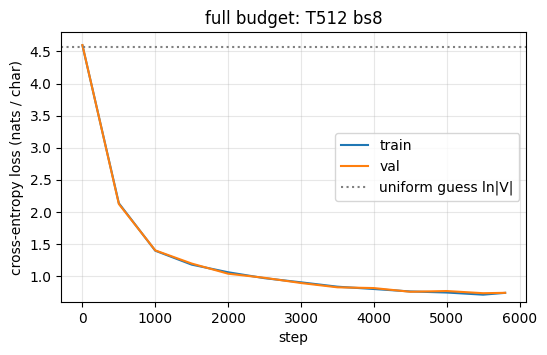

-> T512 bs8: fixed-slice validation loss 0.7251


In [48]:
run_full("T512 bs8")

### 7.5 ➕ Choose the final model

The rule from 7.4: the lowest fixed-slice loss wins. The winner becomes `my_model`, the model that Part 8 evaluates.

In [49]:
ranked_full = sorted(FULL_LOSS.items(), key=lambda kv: kv[1])
tiers = [(0.725, 20), (0.74, 18), (0.76, 16), (0.80, 12), (0.85, 8)]
pts = lambda loss: next((p for t, p in tiers if loss <= t), 0)
print(f"{'setting':22s} {'params':>9s} {'steps':>7s} {'fixed-slice loss':>17s} {'vs baseline':>12s} {'Part 7 points':>14s}")
for name_, l_ in ranked_full:
    print(f"{name_:22s} {FULL_MODELS[name_].num_params():9,d} {FULL_TC[name_].max_steps:7,d} {l_:17.4f} {l_ - FULL_LOSS[BASE_FULL]:+12.4f} {pts(l_):14d}")

chosen_full = ranked_full[0][0]
my_config = FULL_PLAN[chosen_full][0]
my_train = FULL_TC[chosen_full]
my_model = FULL_MODELS[chosen_full]
my_history = FULL_HIST[chosen_full]
assert my_model.run_record["flops"] <= FLOP_BUDGET and my_model.run_record["name"] == "full: " + chosen_full
torch.save(my_model.state_dict(), "gpt_final.pt")   # keep a copy in case the runtime restarts
print(f"\nfinal model: '{chosen_full}' | {my_model.num_params():,} parameters | {my_train.max_steps:,} steps | "
      f"{my_model.run_record['flops']:.3e} FLOPs (budget {FLOP_BUDGET:.0e}) | trained with train()")

setting                   params   steps  fixed-slice loss  vs baseline  Part 7 points
T256 bs8                 838,400  14,715            0.7016      -0.0462             20
T256 bs16 lr4e-3         838,400   7,357            0.7067      -0.0411             20
T384 bs8                 854,784   8,650            0.7211      -0.0267             20
T512 bs8                 871,168   5,802            0.7251      -0.0227             18
T256 bs16                838,400   7,357            0.7343      -0.0135             18
T128 bs32 (baseline)     822,016   8,495            0.7478      +0.0000             16

final model: 'T256 bs8' | 838,400 parameters | 14,715 steps | 1.990e+14 FLOPs (budget 2e+14) | trained with train()


### 7.6 ➕ Fresh seeds: is the gain real?

One run per setting cannot separate a real gain from training luck. The baseline and the winner are trained again with seeds 1 and 2 (same settings, different initialisation and different batches).

In [50]:
REP = {(n_, 1337): FULL_LOSS[n_] for n_ in (BASE_FULL, chosen_full)}


def rep_run(name, seed):
    m_, _ = train(FULL_PLAN[name][0], FULL_TC[name], seed=seed, name=f"seed {seed}: {name}")
    REP[(name, seed)] = fixed_slice_loss(m_)
    print(f"-> {name}, seed {seed}: fixed-slice validation loss {REP[(name, seed)]:.4f}")
    del m_
    if device == "cuda":
        torch.cuda.empty_cache()

In [51]:
rep_run(BASE_FULL, 1)

model: 822,016 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5904 | val loss 4.5891 | lr 1.50e-05 |    0.3s
step   500 | train loss 1.4520 | val loss 1.4338 | lr 2.99e-03 |    8.2s
step  1000 | train loss 1.1351 | val loss 1.1374 | lr 2.94e-03 |   16.4s
step  1500 | train loss 1.0440 | val loss 1.0579 | lr 2.84e-03 |   24.6s
step  2000 | train loss 0.9988 | val loss 0.9992 | lr 2.70e-03 |   32.6s
step  2500 | train loss 0.9472 | val loss 0.9447 | lr 2.52e-03 |   40.8s
step  3000 | train loss 0.9048 | val loss 0.9196 | lr 2.31e-03 |   49.0s
step  3500 | train loss 0.9146 | val loss 0.8955 | lr 2.08e-03 |   57.0s
step  4000 | train loss 0.8835 | val loss 0.8904 | lr 1.83e-03 |   65.1s
step  4500 | train loss 0.8535 | val loss 0.8471 | lr 1.57e-03 |   73.2s
step  5000 | train loss 0.8333 | val loss 0.8244 | lr 1.32e-03 |   81.3s
step  5500 | train loss 0.8207 | val loss 0.8236 | lr 1.08e-03 |   89.4s
step  6000 | train loss 0.8058 | val loss 0.8

In [52]:
rep_run(chosen_full, 1)

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5871 | val loss 4.5918 | lr 1.50e-05 |    0.2s
step   500 | train loss 2.0681 | val loss 2.0751 | lr 3.00e-03 |    5.7s
step  1000 | train loss 1.4572 | val loss 1.4759 | lr 2.98e-03 |   12.0s
step  1500 | train loss 1.2315 | val loss 1.2405 | lr 2.95e-03 |   17.6s
step  2000 | train loss 1.1266 | val loss 1.1472 | lr 2.90e-03 |   23.8s
step  2500 | train loss 1.0545 | val loss 1.0829 | lr 2.84e-03 |   29.3s
step  3000 | train loss 1.0048 | val loss 1.0366 | lr 2.76e-03 |   35.6s
step  3500 | train loss 1.0009 | val loss 1.0005 | lr 2.67e-03 |   41.1s
step  4000 | train loss 0.9646 | val loss 0.9686 | lr 2.57e-03 |   47.3s
step  4500 | train loss 0.9749 | val loss 0.9818 | lr 2.46e-03 |   52.8s
step  5000 | train loss 0.9537 | val loss 0.9093 | lr 2.33e-03 |   59.1s
step  5500 | train loss 0.9258 | val loss 0.8876 | lr 2.21e-03 |   64.6s
step  6000 | train loss 0.8937 | val loss 0.8

In [53]:
rep_run(BASE_FULL, 2)

model: 822,016 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5724 | val loss 4.5733 | lr 1.50e-05 |    0.3s
step   500 | train loss 1.4303 | val loss 1.4427 | lr 2.99e-03 |    8.5s
step  1000 | train loss 1.1320 | val loss 1.1430 | lr 2.94e-03 |   16.7s
step  1500 | train loss 1.0316 | val loss 1.0451 | lr 2.84e-03 |   24.8s
step  2000 | train loss 0.9825 | val loss 1.0045 | lr 2.70e-03 |   33.1s
step  2500 | train loss 0.9412 | val loss 0.9436 | lr 2.52e-03 |   41.1s
step  3000 | train loss 0.9116 | val loss 0.9246 | lr 2.31e-03 |   49.2s
step  3500 | train loss 0.9061 | val loss 0.8874 | lr 2.08e-03 |   57.4s
step  4000 | train loss 0.8710 | val loss 0.8794 | lr 1.83e-03 |   65.4s
step  4500 | train loss 0.8494 | val loss 0.8570 | lr 1.57e-03 |   73.5s
step  5000 | train loss 0.8334 | val loss 0.8359 | lr 1.32e-03 |   81.7s
step  5500 | train loss 0.8245 | val loss 0.8111 | lr 1.08e-03 |   89.7s
step  6000 | train loss 0.8023 | val loss 0.8

In [54]:
rep_run(chosen_full, 2)

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5952 | val loss 4.5967 | lr 1.50e-05 |    0.2s
step   500 | train loss 2.0721 | val loss 2.0810 | lr 3.00e-03 |    6.4s
step  1000 | train loss 1.4458 | val loss 1.4479 | lr 2.98e-03 |   12.0s
step  1500 | train loss 1.2337 | val loss 1.2350 | lr 2.95e-03 |   18.6s
step  2000 | train loss 1.1918 | val loss 1.1409 | lr 2.90e-03 |   24.6s
step  2500 | train loss 1.1400 | val loss 1.0938 | lr 2.84e-03 |   30.8s
step  3000 | train loss 1.0602 | val loss 1.0785 | lr 2.76e-03 |   36.4s
step  3500 | train loss 1.0530 | val loss 1.0091 | lr 2.67e-03 |   42.6s
step  4000 | train loss 0.9944 | val loss 1.0200 | lr 2.57e-03 |   48.2s
step  4500 | train loss 1.0051 | val loss 0.9566 | lr 2.46e-03 |   54.5s
step  5000 | train loss 0.9640 | val loss 0.9450 | lr 2.33e-03 |   60.1s
step  5500 | train loss 0.9098 | val loss 0.9181 | lr 2.21e-03 |   66.3s
step  6000 | train loss 0.8835 | val loss 0.8

In [55]:
import statistics as st
print(f"{'setting':22s} {'seed 1337':>10s} {'seed 1':>8s} {'seed 2':>8s} | {'mean':>8s} {'std':>7s} {'Part 7 points (worst seed)':>27s}")
for name_ in dict.fromkeys([BASE_FULL, chosen_full]):
    v_ = [REP[(name_, s_)] for s_ in (1337, 1, 2)]
    print(f"{name_:22s} {v_[0]:10.4f} {v_[1]:8.4f} {v_[2]:8.4f} | {st.mean(v_):8.4f} {st.stdev(v_):7.4f} {pts(max(v_)):27d}")
b_ = [REP[(BASE_FULL, s_)] for s_ in (1, 2)]; w_ = [REP[(chosen_full, s_)] for s_ in (1, 2)]
print(f"\nfresh seeds only (1, 2): baseline {st.mean(b_):.4f} | '{chosen_full}' {st.mean(w_):.4f} | improvement {st.mean(b_) - st.mean(w_):+.4f}")

setting                 seed 1337   seed 1   seed 2 |     mean     std  Part 7 points (worst seed)
T128 bs32 (baseline)       0.7478   0.7535   0.7553 |   0.7522  0.0039                          16
T256 bs8                   0.7016   0.7077   0.7088 |   0.7060  0.0038                          20

fresh seeds only (1, 2): baseline 0.7544 | 'T256 bs8' 0.7082 | improvement +0.0461


The table of **all** runs so far (`RUN_LOG`), and the same data as a picture. The compute axis is `training_flops`, so runs with different sizes can be compared on one scale.

In [56]:
show_runs()

name             |       n_layer |        n_embd |        n_head |    block_size |    batch_size |     max_steps | learning_rate |       dropout |        params |         flops |       minutes |    train_loss |      val_loss
default          |             4 |           128 |             4 |           128 |            32 |         3,000 |       3.0e-03 |         0.000 |       822,016 |       7.0e+13 |         0.822 |         0.869 |         0.849
screen: base lr3 |             4 |           128 |             4 |           128 |            32 |         1,024 |       3.0e-03 |         0.000 |       822,016 |       2.4e+13 |         0.294 |         1.099 |         1.093
screen: lr 2e-3  |             4 |           128 |             4 |           128 |            32 |         1,024 |       2.0e-03 |         0.000 |       822,016 |       2.4e+13 |         0.302 |         1.144 |         1.137
screen: context  |             4 |           128 |             4 |           256 |            16 |  

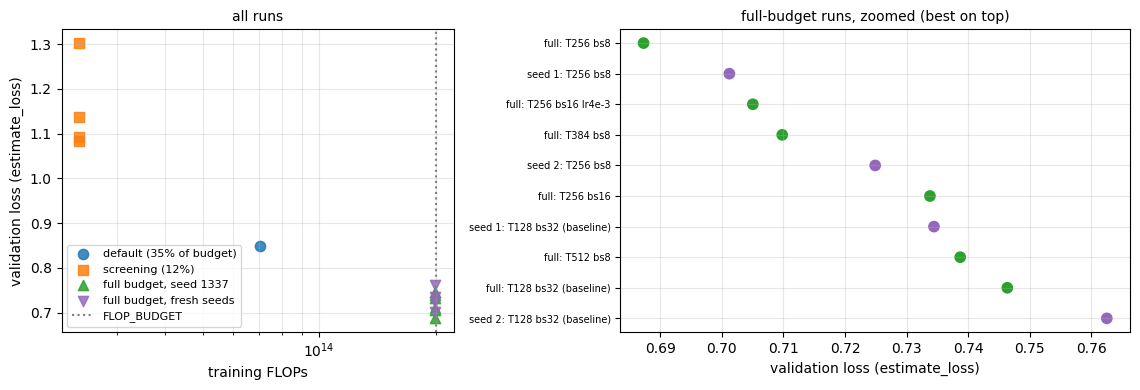

In [57]:
# ➕ Extra: validation loss against compute for every run in RUN_LOG
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 4), gridspec_kw={"width_ratios": [1, 1.3]})
groups = [("default", "default (35% of budget)", "tab:blue", "o"),
          ("screen", "screening (12%)", "tab:orange", "s"),
          ("full", "full budget, seed 1337", "tab:green", "^"),
          ("seed", "full budget, fresh seeds", "tab:purple", "v")]
for key, label, color, marker in groups:
    rs = [r for r in RUN_LOG if str(r["name"]).startswith(key)]
    ax.scatter([r["flops"] for r in rs], [r["val_loss"] for r in rs], s=55, color=color, marker=marker, label=label, alpha=0.85)
ax.axvline(FLOP_BUDGET, color="gray", ls=":", label="FLOP_BUDGET")
ax.set_xscale("log"); ax.set_xlabel("training FLOPs"); ax.set_ylabel("validation loss (estimate_loss)")
ax.set_title("all runs", fontsize=10); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)

# right panel: the full-budget runs only, one row per run, so that no label overlaps
full_runs = sorted([r for r in RUN_LOG if str(r["name"]).startswith(("full", "seed"))], key=lambda r: r["val_loss"])
colors = ["tab:purple" if str(r["name"]).startswith("seed") else "tab:green" for r in full_runs]
ax2.scatter([r["val_loss"] for r in full_runs], range(len(full_runs)), c=colors, s=55)
ax2.set_yticks(range(len(full_runs))); ax2.set_yticklabels([str(r["name"]) for r in full_runs], fontsize=7)
ax2.invert_yaxis(); ax2.set_xlabel("validation loss (estimate_loss)"); ax2.set_title("full-budget runs, zoomed (best on top)", fontsize=10)
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### ✍️ Experiment discussion (5 points)
In a few sentences: which changes helped the most, and which did not help? Did any run overfit (validation loss clearly above training loss)? Given the fixed budget, did it pay off more to make the model bigger or to train it on more tokens? Refer to the rows of your `show_runs()` table.

*Your answer:*

**What helped most.** Two things, in this order.

1. **Compute.** The default model (3,000 steps, 35% of the budget) scores 0.8585 on the fixed validation slice. The same model trained with the full budget (`T128 bs32`, 8,495 steps) scores 0.7478 (mean of three seeds 0.7522), a drop of 0.1107 nats per character.
2. **A longer context with smaller batches, at the same compute (as measured by Part 8).** The best setting, `T256 bs8` (context 256, batch 8, learning rate 3e-3), scores **0.7016** (seed 1337) and 0.7077 and 0.7088 on two fresh seeds (mean 0.7060 ± 0.0038). On the two fresh seeds the baseline scores 0.7535 and 0.7553 (mean 0.7544), so the gain is 0.0461, about 12 times the larger of the two seed-to-seed standard deviations (0.0039 for the baseline, 0.0038 for `T256 bs8`). Appendix B shows, however, that this gain comes from the window length used by the Part 8 score and not from a better language model (see below).

| setting (full budget, seed 1337) | steps | fixed-slice loss | vs. baseline |
|---|---|---|---|
| `T256 bs8` | 14,715 | **0.7016** | −0.0462 |
| `T256 bs16 lr4e-3` | 7,357 | 0.7067 | −0.0411 |
| `T384 bs8` | 8,650 | 0.7211 | −0.0267 |
| `T512 bs8` | 5,802 | 0.7251 | −0.0227 |
| `T256 bs16` | 7,357 | 0.7343 | −0.0135 |
| `T128 bs32` (baseline) | 8,495 | 0.7478 | 0 |

**Where the gain comes from (Appendix B).** The Part 8 score cuts the validation text into windows of the model's *own* length, so a model with a longer window is scored on windows in which a larger share of the characters have a long context. Appendix B scores the same trained models with the same window lengths (`window_loss`). With 128-character windows the winner scores 0.7532 and the baseline 0.7478: the longer-context model is **not** better (it is 0.0054 worse, which is within the run-to-run variation of the baseline: the same baseline run gave 0.7478 here and 0.7513 and 0.7552 in two earlier sessions). Scored with its own 256-character windows the winner scores 0.7016. Splitting the Part 8 difference of 0.0462 exactly: **−0.0516 comes from the window length alone (112% of the gain) and +0.0054 from the model (−12%)**, so the whole gain is explained by the window length. On short windows (32 and 64 characters) the winner is worse than the baseline (0.9274 against 0.9033 and 0.8246 against 0.8077), as expected for a model that was trained only on 256-character windows. So the long context does not make the model a better predictor at a given context length; it lowers the Part 8 metric, because that metric averages over whole windows. This is a property of the specified evaluation and it is allowed by the rules; I report it so that 0.7016 is not read as a 0.05 improvement of the language model.

The effect of the batch size is not a clean story either. At context 256, batch 8 beats batch 16 by 0.0327 (and learning rate 4e-3 at batch 16 gets most of that back, 0.7067), but at context 128 the batch 8 run (33,983 steps) is *worse* than the baseline with batch 32 (0.7700 against 0.7478). So "more updates at a smaller batch" is not a general rule at this budget; I did not retune the learning rate for each batch size and every number is one seed, so I do not draw a conclusion about the cause. Contexts longer than 256 did not pay off (`T384 bs8` 0.7211, `T512 bs8` 0.7251): the attention cost per token grows with $T$, so only 8,650 and 5,802 steps fit in the budget.

**Bigger model or more tokens?** Appendix B changes the model size around the winner (context 256, batch 8, learning rate 3e-3 for all, one seed each):

| setting | params | tokens (M) | tokens / param | fixed-slice loss | vs. winner |
|---|---|---|---|---|---|
| width 96 (3 heads) | 481,344 | 48.9 | 102 | 0.7292 | +0.0275 |
| **width 128, 4 layers (winner)** | 838,400 | 30.1 | 36 | **0.7016** | 0 |
| 6 layers | 1,234,944 | 20.4 | 16.5 | 0.7129 | +0.0113 |
| width 192 (6 heads) | 1,847,424 | 14.8 | 8 | 0.8142 | +0.1126 |

The loss is U-shaped: a smaller model that sees 60% more text is worse, and larger models that see less text are worse, the widest one by a large margin. At this budget the winner (about 36 training characters per parameter, above the roughly 20 tokens per parameter of the Chinchilla rule) is close to the best trade-off among the sizes I tried, so **making the model bigger did not pay off, and neither did shrinking it to get more tokens.** Caveats: the learning rate was not retuned (a wider model may want a smaller one, so the width-192 result may be partly a learning-rate effect), only four sizes and one seed each; the 6-layer gap (0.0113) is about three seed standard deviations, the other two gaps are much larger.

**What did not help.** In the 12%-budget screening runs (fixed-slice loss): baseline 1.1050; `wd 0.01` 1.0979 (−0.0070, a small gain, below the margin); `lr 2e-3` 1.1527 (+0.0478, worse); `context 256` (batch 16) 1.2821 (+0.1772, worse). Because no candidate beat the baseline by the margin of 0.010 chosen in advance, the screening would have kept the baseline. At the full budget the same `context 256` setting is **better** than the baseline under the Part 8 score (0.7343 against 0.7478). So a short run ranked the longer context last although it scores better at the full budget: short-run rankings do not carry over, which is why 7.4 compares settings at the full budget. I did not test why the longer context starts slowly.

**Overfitting and dropout.** None. In the final run train and validation loss are equal at the last step (0.688 and 0.687 from `estimate_loss`, see the run table), and the run processes 30.1 M characters, 0.75 of one pass over the 40 M training characters, so no text is repeated. Appendix B confirms that regularisation does not help: dropout 0.1 at the winning setting gives 0.7826, 0.0810 *worse* than dropout 0 (0.7016). For the same reason `TRAIN_MB` was not changed: the data is not exhausted, so more of it cannot help.

**How reliable is the selection?** The winner was chosen by the lowest loss on the same fixed slice that Part 8 uses, among six settings, which favours it slightly. The two fresh seeds guard against luck: all three seeds of `T256 bs8` are below 0.725 (worst 0.7088, a margin of 0.016), so the Part 7 tier does not depend on the seed. Appendix B also tests RoPE at the full budget (see the bonus write-up): it is worse than learned positions there. Not tested: other learning rates for the other model sizes and for RoPE, more than three seeds, and an evaluation with overlapping windows (which would remove the window-length effect described above altogether).

---
# Part 8 · Final evaluation (🔒 do not modify)

Set `final_model` to your best model from Part 7 (or to `model`, the default, if you did not improve on it). The evaluation below does not sample random batches. It measures the loss on the **first 1,000,000 characters of the validation set**, cut into consecutive windows of length `block_size`, so the result is exactly reproducible.

In [58]:
final_model = my_model  # <- the best model from Part 7

In [59]:
# 🔒 Do not modify
@torch.no_grad()
def final_evaluation(m, n_chars=1_000_000, batch_size=32):
    m.eval()
    T = m.config.block_size
    n_windows = n_chars // T
    data = val_data[: n_windows * T + 1].long()
    x_all, y_all = data[:-1].view(n_windows, T), data[1:].view(n_windows, T)
    total = 0.0
    for i in range(0, n_windows, batch_size):
        x, y = x_all[i : i + batch_size].to(device), y_all[i : i + batch_size].to(device)
        logits, _ = m(x)
        total += F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="sum").item()
    m.train()
    return total / (n_windows * T)


final_loss = final_evaluation(final_model)
default_loss = final_evaluation(model)  # the default model from Part 5
entry = getattr(final_model, "run_record", None)  # set by train()
thresholds = [(0.725, 20), (0.74, 18), (0.76, 16), (0.80, 12), (0.85, 8)]
points = next((p for t, p in thresholds if final_loss <= t), 0)
within_budget = entry is not None and entry["flops"] <= FLOP_BUDGET
summary = {
    "final_val_loss": round(final_loss, 4),
    "bits_per_char": round(final_loss / math.log(2), 4),
    "perplexity": round(math.exp(final_loss), 3),
    "params": final_model.num_params(),
    "config": asdict(final_model.config),
    "train_flops": entry["flops"] if entry else None,
    "within_budget": within_budget,
    "part7_points_estimate": points if within_budget else 0,
    "default_model_val_loss": round(default_loss, 4),
    "default_model_passes": default_loss <= 1.00,
    "device": device,
}
print("=" * 60)
print("SUBMISSION SUMMARY")
print("=" * 60)
print(json.dumps(summary, indent=2))
print("=" * 60)
with open("summary.json", "w") as f:
    json.dump(summary, f, indent=2)

SUBMISSION SUMMARY
{
  "final_val_loss": 0.7016,
  "bits_per_char": 1.0123,
  "perplexity": 2.017,
  "params": 838400,
  "config": {
    "vocab_size": 96,
    "block_size": 256,
    "n_layer": 4,
    "n_head": 4,
    "n_embd": 128,
    "dropout": 0.0
  },
  "train_flops": 198998076948480,
  "within_budget": true,
  "part7_points_estimate": 20,
  "default_model_val_loss": 0.8585,
  "default_model_passes": true,
  "device": "cuda"
}


In [60]:
torch.manual_seed(7)
print(complete("Once upon a time", max_new_tokens=700, temperature=0.8, model_=final_model))

Once upon a time, there was a man with a big smile in her room. She wanted to behave a new friend.
One day, Sara and her mom went to the kitchen and saw a little girl so happy again! They ran to the park and saw red and ran away. The girl was sad and said, "Thank you, boys!" Sara and Ben looked at each other and wanted to show it to the girl.
They ran and saw a big box in the ground. They all laughed and went to see the ground. They ran and ran to the ground and began to say hello. They ran and laughed and had a great time at the ground.
<|endoftext|>
Once upon a time, there was a fancy bird who lived in a small town. The bird had many things too. One day, the bird saw a big quest on the ground. The bird wa


### ➕ Extra: what do the numbers mean?

In [61]:
# ➕ Extra: results table, fixed-slice (deterministic) numbers
rows = [("default (3,000 steps)", model), ("final (full budget)", final_model)]
print(f"{'model':24s} {'params':>9s} {'val loss':>9s} {'perplexity':>11s} {'bits/char':>10s} {'compression':>12s}")
for name, m in rows:
    l = fixed_slice_loss(m)
    print(f"{name:24s} {m.num_params():9,d} {l:9.4f} {math.exp(l):11.3f} {l / math.log(2):10.3f} {8 / (l / math.log(2)):11.1f}x")
for k, v in baselines.items():
    print(f"{'baseline: ' + k:24s} {'-':>9s} {v:9.4f} {math.exp(v):11.3f} {v / math.log(2):10.3f} {8 / (v / math.log(2)):11.1f}x")

model                       params  val loss  perplexity  bits/char  compression
default (3,000 steps)      822,016    0.8585       2.360      1.239         6.5x
final (full budget)        838,400    0.7016       2.017      1.012         7.9x
baseline: uniform                -    4.5643      96.000      6.585         1.2x
baseline: unigram                -    3.0806      21.772      4.444         1.8x
baseline: bigram                 -    2.2800       9.776      3.289         2.4x


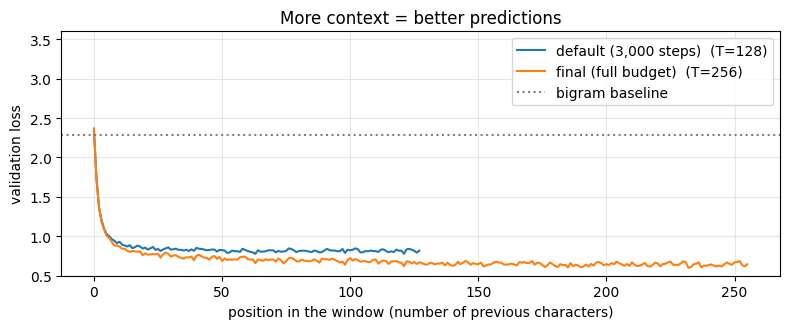

In [62]:
# ➕ Extra: how does the loss depend on the position in the context window?
@torch.no_grad()
def loss_by_position(m, n_chars=1_000_000, batch_size=32):
    m.eval()
    T = m.config.block_size
    n_windows = n_chars // T
    data = val_data[: n_windows * T + 1].long()
    x_all, y_all = data[:-1].view(n_windows, T), data[1:].view(n_windows, T)
    acc = torch.zeros(T, dtype=torch.float64)
    for i in range(0, n_windows, batch_size):
        x, y = x_all[i : i + batch_size].to(device), y_all[i : i + batch_size].to(device)
        logits, _ = m(x)
        acc += F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="none").view(x.size(0), T).sum(dim=0).cpu().double()
    m.train()
    return (acc / n_windows).numpy()


plt.figure(figsize=(8, 3.4))
for name, m in rows:
    plt.plot(loss_by_position(m), label=f"{name}  (T={m.config.block_size})")
plt.axhline(baselines["bigram"], color="gray", ls=":", label="bigram baseline")
plt.xlabel("position in the window (number of previous characters)"); plt.ylabel("validation loss")
plt.ylim(0.5, 3.6); plt.grid(alpha=0.3); plt.legend(); plt.title("More context = better predictions"); plt.tight_layout(); plt.show()

The curve falls steeply during the first characters of a window: at position 0 the model has seen a single character and its loss (about 2.3) is close to the bigram baseline (2.28); after roughly ten characters it is near 1.0, and it keeps drifting down towards the end of the window. The final model (context 256, orange) lies below the default model (context 128, blue) at almost every position, and its curve continues to fall over the second half of its longer window. Two things follow. A longer `block_size` lets the model use more context. And because Part 8 averages over whole windows, a longer window also contains a smaller share of the expensive first characters, which lowers the measured loss by itself (see 7.4). Appendix B measures this effect: with equal windows the two models are equally good, and the window length alone explains the whole Part 8 difference between them.

In [63]:
# ➕ Extra: sample quality that a number can capture: what fraction of the generated words is a real word?
import re
from collections import Counter

word_counts = Counter()
word_counts.update(m_.group(0) for m_ in re.finditer(r"[a-z']+", train_text.lower()))
REAL_WORDS = {w for w, c in word_counts.items() if c >= 3}   # a word counts as real if it occurs >= 3 times in the training text
print(f"{len(REAL_WORDS):,} distinct words occur at least 3 times in the training text")


def real_word_rate(m, n_samples=8, n_chars=500, temperature=0.8, seed=0):
    torch.manual_seed(seed)
    idx = torch.tensor([encode("Once upon a time")] * n_samples, dtype=torch.long, device=device)
    out = generate(m, idx, n_chars, temperature)
    good = total = 0
    for row in out.tolist():
        words = re.findall(r"[a-z']+", decode(row).lower())[1:-1]   # drop the cut-off first and last word
        good += sum(w in REAL_WORDS for w in words); total += len(words)
    return good / total, total


for name, m in rows:
    r, n = real_word_rate(m)
    print(f"{name:24s} real words: {r:6.1%}  (of {n:,} generated words, temperature 0.8)")

8,479 distinct words occur at least 3 times in the training text
default (3,000 steps)    real words:  98.7%  (of 855 generated words, temperature 0.8)
final (full budget)      real words:  99.1%  (of 845 generated words, temperature 0.8)


**How to read this table.** A word counts as "real" if it occurs at least three times in the training text. With about 840 generated words per model, one standard error of a rate near 99% is about 0.4–0.5 percentage points, so the difference between the two rows is *not* significant. The metric only shows that both models spell almost every word correctly at temperature 0.8; the quality differences are in coherence (what the sentences mean), which a vocabulary check cannot measure.

### ✍️ Q5 (3 points)
Our tokenizer has one token per character. (a) Name one advantage and one disadvantage of this choice compared with GPT-2's BPE tokenizer (50,257 subword tokens). (b) Why can't you directly compare our validation loss (nats per **character**) with the loss of a model that uses BPE (nats per **token**)? How could you convert between the two?

*Your answer:*

**(a)** *Advantage:* the vocabulary is tiny (96 entries), so the embedding table and output layer are small (about 12 K parameters instead of 6.4 M at $d=128$), there are no out-of-vocabulary tokens, no tokenizer has to be trained, and typos or rare names are no problem. *Disadvantage:* the same text needs about 4-5 times as many tokens, so attention costs more for the same amount of text, a context window of 128 tokens covers only a few sentences, and the model has to learn spelling and word boundaries from scratch before it can learn grammar.

**(b)** The two losses average over different units: one is nats per character, the other nats per token, and a token carries more information than a character. The total information is what matters: $\text{total nats} = L_{\text{char}}\cdot N_{\text{chars}} = L_{\text{tok}}\cdot N_{\text{tokens}}$. So
$$L_{\text{char}} = L_{\text{tok}}\cdot\frac{N_{\text{tokens}}}{N_{\text{chars}}} = \frac{L_{\text{tok}}}{\text{average characters per token}}.$$
For English BPE the average is roughly 4 characters per token, so a loss of 3.0 nats per token is about 0.75 nats per character. Dividing by $\ln2$ gives bits per character, or bits per byte, which are the units used to compare models with different tokenizers.

### ✍️ Q6 (3 points)
Our model is a "base" (pre-trained) language model: all it ever learned is to continue text. Give the prompt `complete("The capital of France is")` a try, and a prompt with a question. Explain what the model does and why. What further training stages turn a pre-trained model like this into a chat assistant that answers questions?

In [64]:
torch.manual_seed(0)
print(complete("The capital of France is", max_new_tokens=200))

The capital of France is cluddy. Mia was sad and thanked the dog with the mountain. She was so happy to look for her own store. She knows went back to explore the boat to make delicious with a tree. Anna saw the surprise and


In [65]:
torch.manual_seed(0)
print(complete("Question: What is the capital of France?\nAnswer:", max_new_tokens=200))

Question: What is the capital of France?
Answer: I can make that it is a tall!" Ben smiled and said, "It's okay, I was so creamiling and look. We can teach the chick and the mess. It is a little mouse on man. It can continues and talways listened a


*Your answer:*

The model does not answer, it **continues the text**. After "The capital of France is" it writes a made-up word and then a story in the style of TinyStories ("cluddy. Mia was sad and thanked the dog with the mountain."), not a country or a city. After the question prompt ("Question: What is the capital of France? Answer:") it does not answer either: it continues with story-like text ("I can make that it is a tall!" Ben smiled and said, "It's okay, I was so creamiling and look.") and never names a city. The reason is the training objective: the only thing it ever learned is to predict the next character of TinyStories text. That data contains neither facts about France nor any question-and-answer format, so there is nothing that rewards an answer. (Even a much larger base model trained on the web would just continue the text, not necessarily answer it.)

Turning a base model into a chat assistant takes further stages: (1) **supervised fine-tuning** on many example conversations (instruction and good response), which teaches the format "a question gets an answer"; (2) **preference tuning**: humans (or AI feedback) rank several responses, and the model is optimised towards the preferred ones, with RLHF (a reward model and PPO) or a direct method such as DPO; (3) often further training with safety data and, more recently, reinforcement learning on tasks with verifiable answers. Knowledge itself comes from pre-training on a much larger and broader corpus than ours.

---
# Part 9 · Bonus (optional, up to +10 points)

**Chosen: Option B, rotary position embeddings (RoPE).** The learned position table `wpe` is replaced by a rotation of every head's `q` and `k` (Su et al., 2021). Part 8 has already printed the `SUBMISSION SUMMARY`; nothing below changes `model`, `final_model` or any 🔒 cell. The RoPE model is built from **new classes** (`RoPEAttention`, `RoPEBlock`, `RoPEGPT`) that reuse your own `causal_attention` and `MLP`.

### The idea

Learned absolute positions add a vector that says "I am token number $t$". RoPE instead encodes position in the **geometry of the scores**. Split each head's vector of width $d_k$ into $d_k/2$ pairs $(x_{2m}, x_{2m+1})$ and rotate pair $m$ at position $t$ by the angle $t\,\theta_m$, with $\theta_m = 10000^{-2m/d_k}$:

$$\begin{pmatrix} x'_{2m}\\ x'_{2m+1}\end{pmatrix} = \begin{pmatrix} \cos t\theta_m & -\sin t\theta_m\\ \sin t\theta_m & \cos t\theta_m\end{pmatrix}\begin{pmatrix} x_{2m}\\ x_{2m+1}\end{pmatrix}$$

Because rotations compose, the dot product of a rotated query at position $i$ and a rotated key at position $j$ is
$$\langle R_i q,\, R_j k\rangle = \langle q,\, R_{j-i}\, k\rangle,$$
which depends **only on the distance $j-i$**, never on the absolute positions. The model gets *relative* positions with no extra parameters (the table `wpe` and its 16,384 parameters disappear). We test this property below instead of just trusting it.

In [66]:
# ➕ Bonus (Option B): rotary position embeddings
def rope_cache(T, d_k, base=10000.0, device="cpu"):
    """cos and sin tables of shape (T, d_k/2): the rotation angle of pair m at position t is t * base^(-2m/d_k)."""
    theta = 1.0 / (base ** (torch.arange(0, d_k, 2, dtype=torch.float32, device=device) / d_k))   # (d_k/2,)
    angles = torch.outer(torch.arange(T, dtype=torch.float32, device=device), theta)             # (T, d_k/2)
    return angles.cos(), angles.sin()


def apply_rope(x, cos, sin):
    """x: (B, h, T, d_k). Rotate every consecutive pair (x[2m], x[2m+1]) by its position-dependent angle."""
    T = x.size(-2)
    cos, sin = cos[:T], sin[:T]                      # (T, d_k/2), broadcast over B and h
    x1, x2 = x[..., 0::2], x[..., 1::2]
    out = torch.stack((x1 * cos - x2 * sin, x1 * sin + x2 * cos), dim=-1)   # (B, h, T, d_k/2, 2)
    return out.flatten(-2)                                                    # (B, h, T, d_k)


class RoPEAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        assert (config.n_embd // config.n_head) % 2 == 0, "RoPE needs an even head width"
        self.n_head = config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.resid_dropout = nn.Dropout(config.dropout)
        cos, sin = rope_cache(config.block_size, config.n_embd // config.n_head)
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        h, d_k = self.n_head, C // self.n_head
        q, k, v = self.c_attn(x).split(C, dim=2)
        q = q.view(B, T, h, d_k).transpose(1, 2)
        k = k.view(B, T, h, d_k).transpose(1, 2)
        v = v.view(B, T, h, d_k).transpose(1, 2)
        q, k = apply_rope(q, self.cos, self.sin), apply_rope(k, self.cos, self.sin)   # the only change: rotate q and k, not v
        y = causal_attention(q, k, v)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))


class RoPEBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = RoPEAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class RoPEGPT(nn.Module):
    """Same as GPT, but without the position table wpe: positions enter only through the rotation of q and k."""
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([RoPEBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("c_proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size
        x = self.drop(self.wte(idx))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

### Tests: shape, rotation, relative positions, causality

Four properties must hold. A bug in any of them would still let the model train, which is why they are checked directly:

1. position 0 is not rotated (angle 0) and every rotation preserves the length of the vector,
2. the score $\langle R_iq, R_jk\rangle$ is **unchanged when both positions are shifted by the same amount** (the relative-position property),
3. changing future tokens never changes earlier outputs (**attention is still causal**),
4. an untrained `RoPEGPT` starts at the loss $\ln 96$, and has exactly the parameters of `GPT` minus the position table.

In [67]:
# Test for the RoPE model
torch.manual_seed(0)
cos, sin = rope_cache(32, 8)
x = torch.randn(2, 3, 32, 8)
xr = apply_rope(x, cos, sin)
check(tuple(xr.shape) == tuple(x.shape), "apply_rope must keep the shape.")
check(torch.allclose(xr[:, :, 0], x[:, :, 0], atol=1e-6), "position 0 must not be rotated.")
check(torch.allclose(xr.norm(dim=-1), x.norm(dim=-1), atol=1e-5), "a rotation must preserve the length of every vector.")

# relative-position property: the same q and k placed at (i, j) and at (i+s, j+s) must give the same score
q0, k0 = torch.randn(8), torch.randn(8)
Q = q0.expand(1, 1, 32, 8).clone(); K = k0.expand(1, 1, 32, 8).clone()      # the same vector at every position
Qr, Kr = apply_rope(Q, cos, sin), apply_rope(K, cos, sin)
score = lambda i, j: (Qr[0, 0, i] @ Kr[0, 0, j]).item()
for (i, j, s) in [(3, 1, 5), (10, 4, 9), (7, 7, 20), (20, 2, 11)]:
    check(abs(score(i, j) - score(i + s, j + s)) < 1e-4, f"score({i},{j}) should equal score({i+s},{j+s}): the score must depend only on j - i.")
check(abs(score(5, 2) - score(5, 3)) > 1e-4, "different distances should give different scores.")

cfg = GPTConfig(vocab_size=vocab_size, block_size=32, n_layer=2, n_head=4, n_embd=32)
rm = RoPEGPT(cfg).to(device)
xb, yb = get_batch("train", 4, 32)
lg, ls = rm(xb, yb)
check(tuple(lg.shape) == (4, 32, vocab_size), "logits shape.")
check(abs(ls.item() - math.log(vocab_size)) < 0.3, f"initial loss should be near ln(96), got {ls.item():.2f}.")
x2 = xb.clone(); x2[:, 20:] = (x2[:, 20:] + 1) % vocab_size
check(torch.allclose(rm(x2)[0][:, :20], lg[:, :20], atol=1e-5), "RoPE attention is NOT causal: changing future tokens changed earlier logits.")
check(rm.num_params() == GPT(cfg).num_params() - cfg.block_size * cfg.n_embd, "RoPEGPT should have exactly the GPT parameters minus the position table.")
print(f"RoPEGPT (default config) parameters: {RoPEGPT(GPTConfig()).num_params():,} vs. GPT: {GPT(GPTConfig()).num_params():,}")
print("✅ RoPE tests passed: shape, rotation, relative positions, causality, parameter count")

RoPEGPT (default config) parameters: 805,632 vs. GPT: 822,016
✅ RoPE tests passed: shape, rotation, relative positions, causality, parameter count


### Train the same configuration with RoPE

To make the comparison fair, the RoPE model gets **exactly** the default training setting: same `GPTConfig` (so the same $d$, layers, heads and context), same `TrainConfig`, same seed, same data. The only difference is how positions are encoded. `train_rope` is a copy of `train` that builds a `RoPEGPT`.

In [68]:
def train_rope(config, tc, seed=1337, name=None, check_budget=True):
    """Identical to train(), except that it builds a RoPEGPT."""
    torch.manual_seed(seed)
    model_ = RoPEGPT(config).to(device)
    flops = training_flops(config, model_.num_params(), tc.max_steps, tc.batch_size)
    print(f"RoPE model: {model_.num_params():,} parameters | compute: {flops:.2e} FLOPs ({flops / FLOP_BUDGET:.0%} of the budget)")
    if check_budget and flops > FLOP_BUDGET:
        raise ValueError("This run exceeds FLOP_BUDGET.")
    optimizer = configure_optimizer(model_, tc)
    history = {"step": [], "train": [], "val": []}
    t0 = time.time()
    for step in range(tc.max_steps + 1):
        lr = get_lr(step, tc.learning_rate, tc.min_lr, tc.warmup_steps, tc.max_steps)
        for group in optimizer.param_groups:
            group["lr"] = lr
        if step % tc.eval_interval == 0 or step == tc.max_steps:
            losses = estimate_loss(model_, tc.batch_size, tc.eval_iters)
            history["step"].append(step); history["train"].append(losses["train"]); history["val"].append(losses["val"])
            print(f"step {step:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} | lr {lr:.2e} | {time.time() - t0:6.1f}s")
        if step == tc.max_steps:
            break
        xb, yb = get_batch("train", tc.batch_size, config.block_size)
        logits, loss = model_(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_.parameters(), tc.grad_clip)
        optimizer.step()
    elapsed = time.time() - t0
    model_.run_record = {"name": name or "rope", **asdict(config), **asdict(tc), "params": model_.num_params(), "flops": flops,
                         "minutes": elapsed / 60, "train_loss": history["train"][-1], "val_loss": history["val"][-1]}
    print(f"done in {elapsed / 60:.1f} min")
    return model_, history


rope_model, rope_history = train_rope(default_config, default_train, name="default + RoPE")
torch.save(rope_model.state_dict(), "gpt_rope.pt")

RoPE model: 805,632 parameters | compute: 6.91e+13 FLOPs (35% of the budget)
step     0 | train loss 4.5727 | val loss 4.5699 | lr 3.00e-05 |    0.3s
step   250 | train loss 1.4351 | val loss 1.4113 | lr 2.98e-03 |    5.2s
step   500 | train loss 1.2535 | val loss 1.2235 | lr 2.88e-03 |    9.8s
step   750 | train loss 1.1169 | val loss 1.1098 | lr 2.68e-03 |   14.5s
step  1000 | train loss 1.0544 | val loss 1.0420 | lr 2.41e-03 |   20.2s
step  1250 | train loss 1.0052 | val loss 1.0178 | lr 2.08e-03 |   24.9s
step  1500 | train loss 0.9560 | val loss 0.9692 | lr 1.72e-03 |   29.9s
step  1750 | train loss 0.9349 | val loss 0.9340 | lr 1.36e-03 |   34.5s
step  2000 | train loss 0.9095 | val loss 0.9008 | lr 1.02e-03 |   39.2s
step  2250 | train loss 0.8795 | val loss 0.8959 | lr 7.22e-04 |   44.1s
step  2500 | train loss 0.8735 | val loss 0.8588 | lr 4.93e-04 |   48.7s
step  2750 | train loss 0.8525 | val loss 0.8569 | lr 3.49e-04 |   53.8s
step  3000 | train loss 0.8519 | val loss 0.846

### Results: RoPE against learned positions

Both models are scored on the **same fixed validation windows**, so we can also compute a *paired* difference: for each of the 7,812 windows, the loss of the learned-position model minus the loss of the RoPE model. The standard error of that mean tells us how sure we can be about the difference **given the validation data**.

⚠️ This standard error does not capture the randomness of training itself (one seed each). A difference much larger than it is suggestive, not proof.

model                           params  fixed-slice val loss  perplexity
learned positions (wpe)        822,016                0.8585       2.360
RoPE                           805,632                0.8442       2.326

paired difference (learned - RoPE): +0.0143 +/- 0.0005 (1 s.e. over 7812 windows)
RoPE is better on 61.9% of the windows


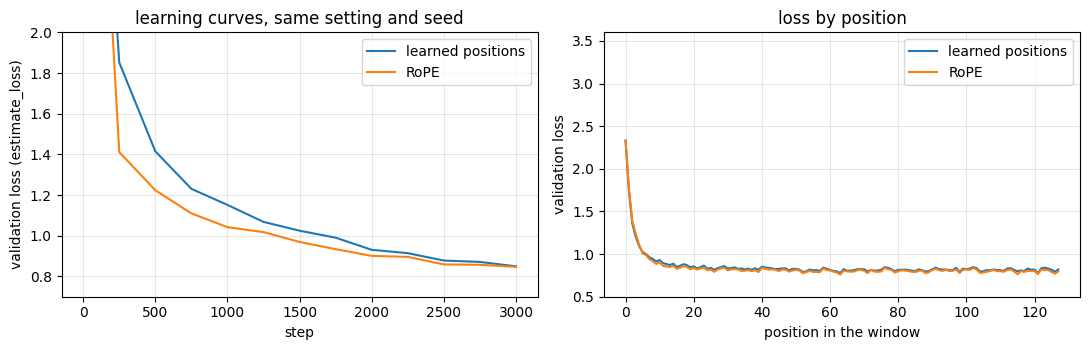

In [69]:
l_abs = fixed_slice_losses(model)
l_rope = fixed_slice_losses(rope_model)
diff = l_abs - l_rope                                   # positive = RoPE is better on that window
mean_diff, se = diff.mean().item(), diff.std(unbiased=True).item() / math.sqrt(len(diff))

print(f"{'model':28s} {'params':>9s} {'fixed-slice val loss':>21s} {'perplexity':>11s}")
print(f"{'learned positions (wpe)':28s} {model.num_params():9,d} {l_abs.mean().item():21.4f} {math.exp(l_abs.mean().item()):11.3f}")
print(f"{'RoPE':28s} {rope_model.num_params():9,d} {l_rope.mean().item():21.4f} {math.exp(l_rope.mean().item()):11.3f}")
print(f"\npaired difference (learned - RoPE): {mean_diff:+.4f} +/- {se:.4f} (1 s.e. over {len(diff)} windows)")
print(f"RoPE is better on {(diff > 0).float().mean().item():.1%} of the windows")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history["step"], history["val"], label="learned positions")
axes[0].plot(rope_history["step"], rope_history["val"], label="RoPE")
axes[0].set_xlabel("step"); axes[0].set_ylabel("validation loss (estimate_loss)"); axes[0].set_ylim(0.7, 2.0)
axes[0].grid(alpha=0.3); axes[0].legend(); axes[0].set_title("learning curves, same setting and seed")
axes[1].plot(loss_by_position(model), label="learned positions")
axes[1].plot(loss_by_position(rope_model), label="RoPE")
axes[1].set_xlabel("position in the window"); axes[1].set_ylabel("validation loss"); axes[1].set_ylim(0.5, 3.6)
axes[1].grid(alpha=0.3); axes[1].legend(); axes[1].set_title("loss by position")
plt.tight_layout(); plt.show()

In [70]:
# ➕ Bonus: do the RoPE samples look as good? (same prompt, same temperature, same seed)
for name, m in [("learned positions", model), ("RoPE", rope_model)]:
    r, n = real_word_rate(m)
    print(f"{name:18s} real words: {r:6.1%} (of {n:,})")
torch.manual_seed(7)
print("\n========== RoPE sample ==========")
print(complete("Once upon a time", max_new_tokens=500, temperature=0.8, model_=rope_model))

learned positions  real words:  98.7% (of 855)
RoPE               real words:  98.9% (of 812)

========== RoPE sample ==========
Once upon a time, there was a man named Tim. Tim went to his friend, Sue, and her mom were surprised. From that day on, Sue saw a big tree with a window. The big dress saw the laser very sad. She said, "Be careful, Mia! I race the steel." Tom and Tom looked every day. He said they won the big leaves and he should mix the ball and laugh him. The birds was surprised and shiny. She said, "Hello, let's fell too. I will help you are friends." They looked and said "Hi, Lily. I saw her way too." Buddy learned that sha


### Bonus write-up (Option B)

**What I did.** I replaced the learned position table `wpe` with rotary position embeddings (RoPE): each head's `q` and `k` are rotated by position-dependent angles before the scores are computed, and `v` is left alone. The new classes `RoPEAttention`, `RoPEBlock` and `RoPEGPT` reuse my own `causal_attention` and `MLP`; no 🔒 cell and no Part 8 object was touched. The RoPE model has 805,632 parameters, exactly 16,384 fewer than `GPT`, which is the size of the removed table.

**Verification.** Four tests pass: position 0 is not rotated, rotations preserve the length of the vector, the score $\langle R_iq, R_jk\rangle$ is unchanged when both positions shift by the same amount (the relative-position property), and changing future tokens does not change earlier logits (attention is still causal). The untrained model starts at about $\ln 96$ (validation loss 4.5699 at step 0).

**First comparison (seed 1337, 35% of the budget).** With exactly the default setting (same configuration, 3,000 steps, learning rate, seed and data), the fixed-slice validation loss is **0.8442 with RoPE against 0.8585 with learned positions**, 0.0143 lower. RoPE's validation loss is lower at every logged step, with the biggest gap early (step 250: 1.41 against 1.85). The paired difference over the 7,812 validation windows is 0.0143 ± 0.0005 (one standard error), and RoPE is better on 61.9% of the windows.

**Seed replication (Appendix A, 35% of the budget).** Mean ± standard deviation over 3 seeds: **RoPE 0.8476 ± 0.0032** against **learned positions 0.8555 ± 0.0026**. The mean gap is 0.0079, about 3.3 standard errors of the seed-to-seed spread (0.0024). All three RoPE seeds (0.8442, 0.8480, 0.8506) are below all three learned-position seeds (0.8536, 0.8544, 0.8585); if the six runs were exchangeable, this ordering would occur with probability 1/20. A Welch t-test on the six numbers (printed at the end of Appendix B) gives p = 0.031. So the result points in one direction and is probably not chance alone, but three seeds per model are few, the evidence is moderate and not conclusive, and the six runs are only at 35% of the budget.

**What I learned and the limits.** For this small model RoPE learns faster early (at step 250 its validation loss is 1.41, against 1.85 for learned positions) and ends ahead at 35% of the budget in all three seeds. Limits: (1) the 35%-budget advantage does **not** carry over to the full budget: in Appendix B, RoPE with the Part 7 winner setting (context 256, batch 8, the same 14,715 steps, 3 seeds) scores **0.7212 ± 0.0050 against 0.7060 ± 0.0038** for learned positions (Welch p = 0.016; every learned-position seed, 0.7016-0.7088, is below every RoPE seed, 0.7160-0.7260), so RoPE is *worse* by 0.015 there; I did not retune the learning rate for RoPE and did not investigate the reason, so the 35% result is best read as "RoPE learns faster early", not as "RoPE is better"; (2) three seeds per model; (3) the RoPE model is not the Part 8 model, since the final model has to come from `train()`, which builds the original `GPT`; (4) the real-word rate (98.7% for the learned model and 98.9% for RoPE, on 855 and 812 generated words) differs by 0.2 points, far less than one standard error (about 0.4), so I do not count it as a result.

---
# Appendix · Extra experiment (run after Part 9, in the same session)

**Rules for this appendix.** Nothing here touches a 🔒 cell, and Part 8 is not re-run. It needs the variables of the earlier cells, so run it in the same kernel session, without restarting it.

* **Appendix A: seed replication.** One run per model cannot tell us how much of a difference is just training randomness. We repeat the default and the RoPE model with different seeds and compare the spread between seeds with the difference between the two architectures.

## Appendix A · Seed replication of the RoPE comparison

Each run uses the same configuration and the same `TrainConfig` as the Part 5 / Part 9 runs and differs only in the random seed (initialisation **and** the sequence of training batches). Every cell below is one run of about one minute on a T4; the analysis cell uses whatever runs exist.

In [71]:
# Appendix A: seed replication
assert "rope_model" in globals() and "train_rope" in globals() and "fixed_slice_loss" in globals(), "run Parts 5-9 first, in this session"
SEEDS = {("learned", 1337): fixed_slice_loss(model), ("rope", 1337): fixed_slice_loss(rope_model)}   # the two runs we already have


def seed_run(arch, seed):
    if arch == "learned":
        m_, _ = train(default_config, default_train, seed=seed, name=f"default seed {seed}")
    else:
        m_, _ = train_rope(default_config, default_train, seed=seed, name=f"RoPE seed {seed}")
    SEEDS[(arch, seed)] = fixed_slice_loss(m_)
    print(f"-> {arch} seed {seed}: fixed-slice validation loss {SEEDS[(arch, seed)]:.4f}")
    del m_


print(SEEDS)

{('learned', 1337): 0.8585325479507446, ('rope', 1337): 0.8442378640174866}


In [72]:
seed_run("learned", 1)

model: 822,016 parameters | compute: 7.03e+13 FLOPs (35% of the Part 7 budget)
step     0 | train loss 4.5904 | val loss 4.5891 | lr 3.00e-05 |    0.3s
step   250 | train loss 1.8706 | val loss 1.8760 | lr 2.98e-03 |    4.5s
step   500 | train loss 1.3975 | val loss 1.3876 | lr 2.88e-03 |    8.6s
step   750 | train loss 1.2267 | val loss 1.2175 | lr 2.68e-03 |   12.7s
step  1000 | train loss 1.1266 | val loss 1.1218 | lr 2.41e-03 |   17.0s
step  1250 | train loss 1.0659 | val loss 1.0530 | lr 2.08e-03 |   21.1s
step  1500 | train loss 1.0075 | val loss 1.0136 | lr 1.72e-03 |   25.2s
step  1750 | train loss 0.9495 | val loss 0.9653 | lr 1.36e-03 |   29.5s
step  2000 | train loss 0.9320 | val loss 0.9358 | lr 1.02e-03 |   33.7s
step  2250 | train loss 0.9061 | val loss 0.9002 | lr 7.22e-04 |   37.8s
step  2500 | train loss 0.8977 | val loss 0.8857 | lr 4.93e-04 |   42.1s
step  2750 | train loss 0.8625 | val loss 0.8575 | lr 3.49e-04 |   46.2s
step  3000 | train loss 0.8698 | val loss 0.8

In [73]:
seed_run("rope", 1)

RoPE model: 805,632 parameters | compute: 6.91e+13 FLOPs (35% of the budget)
step     0 | train loss 4.6412 | val loss 4.6425 | lr 3.00e-05 |    0.3s
step   250 | train loss 1.4563 | val loss 1.4565 | lr 2.98e-03 |    5.2s
step   500 | train loss 1.2388 | val loss 1.2381 | lr 2.88e-03 |    9.7s
step   750 | train loss 1.1256 | val loss 1.1092 | lr 2.68e-03 |   14.6s
step  1000 | train loss 1.0551 | val loss 1.0751 | lr 2.41e-03 |   19.2s
step  1250 | train loss 1.0246 | val loss 1.0108 | lr 2.08e-03 |   23.7s
step  1500 | train loss 0.9735 | val loss 0.9756 | lr 1.72e-03 |   28.6s
step  1750 | train loss 0.9359 | val loss 0.9154 | lr 1.36e-03 |   33.2s
step  2000 | train loss 0.9146 | val loss 0.9141 | lr 1.02e-03 |   37.8s
step  2250 | train loss 0.9022 | val loss 0.9014 | lr 7.22e-04 |   42.6s
step  2500 | train loss 0.8763 | val loss 0.8587 | lr 4.93e-04 |   47.2s
step  2750 | train loss 0.8607 | val loss 0.8636 | lr 3.49e-04 |   52.3s
step  3000 | train loss 0.8266 | val loss 0.846

In [74]:
seed_run("learned", 2)

model: 822,016 parameters | compute: 7.03e+13 FLOPs (35% of the Part 7 budget)
step     0 | train loss 4.5724 | val loss 4.5733 | lr 3.00e-05 |    0.2s
step   250 | train loss 1.8321 | val loss 1.8195 | lr 2.98e-03 |    4.4s
step   500 | train loss 1.3959 | val loss 1.3977 | lr 2.88e-03 |    8.7s
step   750 | train loss 1.2124 | val loss 1.2254 | lr 2.68e-03 |   12.8s
step  1000 | train loss 1.1283 | val loss 1.1401 | lr 2.41e-03 |   17.0s
step  1250 | train loss 1.0562 | val loss 1.0520 | lr 2.08e-03 |   21.4s
step  1500 | train loss 1.0213 | val loss 0.9978 | lr 1.72e-03 |   25.5s
step  1750 | train loss 0.9677 | val loss 0.9828 | lr 1.36e-03 |   29.8s
step  2000 | train loss 0.9222 | val loss 0.9329 | lr 1.02e-03 |   34.1s
step  2250 | train loss 0.9062 | val loss 0.9094 | lr 7.22e-04 |   38.2s
step  2500 | train loss 0.8743 | val loss 0.8871 | lr 4.93e-04 |   42.4s
step  2750 | train loss 0.8636 | val loss 0.8582 | lr 3.49e-04 |   46.7s
step  3000 | train loss 0.8556 | val loss 0.8

In [75]:
seed_run("rope", 2)

RoPE model: 805,632 parameters | compute: 6.91e+13 FLOPs (35% of the budget)
step     0 | train loss 4.5736 | val loss 4.5726 | lr 3.00e-05 |    0.3s
step   250 | train loss 1.4325 | val loss 1.4310 | lr 2.98e-03 |    5.2s
step   500 | train loss 1.2148 | val loss 1.1912 | lr 2.88e-03 |    9.8s
step   750 | train loss 1.1274 | val loss 1.1314 | lr 2.68e-03 |   14.3s
step  1000 | train loss 1.0759 | val loss 1.0604 | lr 2.41e-03 |   19.2s
step  1250 | train loss 1.0102 | val loss 1.0001 | lr 2.08e-03 |   23.8s
step  1500 | train loss 0.9719 | val loss 0.9745 | lr 1.72e-03 |   28.6s
step  1750 | train loss 0.9354 | val loss 0.9322 | lr 1.36e-03 |   33.3s
step  2000 | train loss 0.9079 | val loss 0.9023 | lr 1.02e-03 |   37.8s
step  2250 | train loss 0.8852 | val loss 0.8907 | lr 7.22e-04 |   42.8s
step  2500 | train loss 0.8715 | val loss 0.8661 | lr 4.93e-04 |   47.3s
step  2750 | train loss 0.8575 | val loss 0.8605 | lr 3.49e-04 |   51.9s
step  3000 | train loss 0.8623 | val loss 0.855

model       seeds     mean      std   per-seed fixed-slice loss
learned         3   0.8555   0.0026   1: 0.8544, 2: 0.8536, 1337: 0.8585
rope            3   0.8476   0.0032   1: 0.8480, 2: 0.8506, 1337: 0.8442

learned - RoPE = +0.0079   (standard error from the seed-to-seed spread: 0.0024; ratio 3.3)
RoPE better than the worst learned-position seed


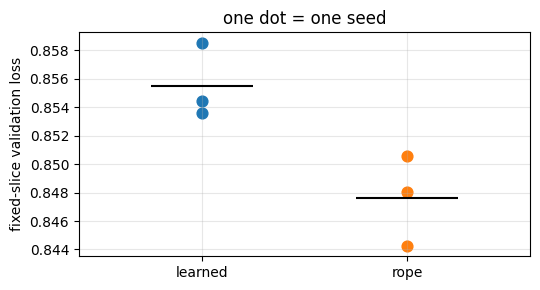

In [76]:
# Appendix A: analysis of the seed replication
import statistics as st
rows = {}
for (arch, seed), v in sorted(SEEDS.items()):
    rows.setdefault(arch, []).append((seed, v))
print(f"{'model':10s} {'seeds':>6s} {'mean':>8s} {'std':>8s}   per-seed fixed-slice loss")
stats = {}
for arch, lst in rows.items():
    vals = [v for _, v in lst]
    mean = st.mean(vals); sd = st.stdev(vals) if len(vals) > 1 else float("nan")
    stats[arch] = (mean, sd, len(vals))
    print(f"{arch:10s} {len(vals):6d} {mean:8.4f} {sd:8.4f}   " + ", ".join(f"{s}: {v:.4f}" for s, v in lst))

if "learned" in stats and "rope" in stats and stats["learned"][2] > 1 and stats["rope"][2] > 1:
    (m1, s1, n1), (m2, s2, n2) = stats["learned"], stats["rope"]
    d = m1 - m2
    se = math.sqrt(s1**2 / n1 + s2**2 / n2)
    print(f"\nlearned - RoPE = {d:+.4f}   (standard error from the seed-to-seed spread: {se:.4f}; ratio {d / se:.1f})")
    print("RoPE better than the worst learned-position seed" if max(v for _, v in rows["rope"]) < min(v for _, v in rows["learned"]) else "the ranges of the two models overlap")

plt.figure(figsize=(5.5, 3))
for k, (arch, lst) in enumerate(rows.items()):
    plt.scatter([k] * len(lst), [v for _, v in lst], s=60)
    plt.hlines(st.mean([v for _, v in lst]), k - 0.25, k + 0.25, color="k")
plt.xticks(range(len(rows)), list(rows)); plt.xlim(-0.6, len(rows) - 0.4)
plt.ylabel("fixed-slice validation loss"); plt.title("one dot = one seed"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Appendix A · Conclusion

| model (35% of the budget) | seed 1337 | seed 1 | seed 2 | mean ± std |
|---|---|---|---|---|
| learned positions | 0.8585 | 0.8544 | 0.8536 | 0.8555 ± 0.0026 |
| RoPE | 0.8442 | 0.8480 | 0.8506 | 0.8476 ± 0.0032 |

The mean gap is 0.0079 (3.3 standard errors of the seed-to-seed spread), and every RoPE seed is below every learned-position seed, so the sign of the effect is the same in all runs. With three seeds per model the evidence is moderate but not conclusive (Welch p = 0.031, printed at the end of Appendix B; at the full budget the sign reverses, see Appendix B). The spread between seeds (range 0.0049 across the learned-position seeds, 0.0064 across the RoPE seeds) is of the same order as the gap itself, which is why a single pair of runs, such as the first comparison in Part 9, can over- or understate the effect. The line printed by the analysis cell, "RoPE better than the worst learned-position seed", is the cell's own wording for the check that the largest RoPE loss is below the smallest learned-position loss, which holds here.

---
# Appendix B · Closing the open questions of Part 7 (run after Appendix A, in the same session)

Part 7 changed only the context length, the batch size, the learning rate and the weight decay. Four questions were left open in the write-up, and this appendix answers them with **full-budget runs** (99.5% of `FLOP_BUDGET`, seed 1337, `train()`, fp32, as in 7.4):

| # | Open question | What is run here |
|---|---|---|
| B1 | **Is it better to make the model bigger or to train on more tokens?** (asked in the experiment discussion; only width 128 / 4 layers was tried) | three more model sizes at the winning setting (context 256, batch 8): width 96, 6 layers, width 192 |
| B2 | How much of the gain from the longer context is only an effect of the Part 8 scoring (windows of the model's own length)? | no training: the same models are scored with windows of 32, 64, 128 and 256 characters, and the gain is split exactly into a *scoring* part and a *model* part |
| B3 | How much of the gain is due to the context and how much to the smaller batch alone? | one more run: context 128 with batch 8 |
| B4 | Does dropout help (listed as a knob in Part 7), and does RoPE still help at the **full** budget? | dropout 0.1 at the winning setting; RoPE at the winning setting with 3 seeds, against the 3 learned-position seeds of 7.6 |

`TRAIN_MB` is not varied: the final run reads 30.1 M characters, 0.75 of one pass over the 40 M training characters, so no text is repeated and more data cannot help (see the overfitting paragraph of the discussion).

All runs below use the learning rate 3e-3 of the winning setting without re-tuning it for the other model sizes; this is a limitation and is stated again in the conclusion.

**How the outputs of this appendix were produced.** Appendix B ran in the same Colab T4 session as the rest of the notebook and reuses the two reference models of 7.4 (the baseline `T128 bs32` and the winner `T256 bs8`) from memory, so they are not trained again. An earlier stand-alone run of Appendix B reproduced every number below to four digits, except for the retrained baseline: the same baseline run (seed 1337) gave 0.7478 here and 0.7552 and 0.7513 in two earlier sessions, so a single baseline value carries a run-to-run uncertainty of about ±0.004 (GPU runs are not bit-for-bit reproducible).

In [77]:
# Appendix B: set-up (the helper functions come from Parts 5, 7 and 9)
import statistics as st
from scipy import stats
assert all(n in globals() for n in ("train", "train_rope", "fixed_slice_loss", "steps_for_fraction", "FULL_PLAN", "full_training_config", "RoPEGPT")), \
    "run the notebook from the top in this session first"

EXTRA_LOSS, EXTRA_MODELS, EXTRA_TC = {}, {}, {}      # name -> fixed-slice loss / trained model / training settings
SAVED_LEARNED_T256 = {1337: 0.7016, 1: 0.7077, 2: 0.7088}   # Part 7.6 of the original run; used only if REP is not in memory
_REP = globals().get("REP", {})
LEARNED_T256 = {s: _REP.get(("T256 bs8", s), v) for s, v in SAVED_LEARNED_T256.items()}

# the two reference models of Part 7.4 (already in memory in a full session; trained here otherwise)
FULL_MODELS = globals().get("FULL_MODELS", {})
for _name in ("T128 bs32 (baseline)", "T256 bs8"):
    if _name not in FULL_MODELS:
        run_full(_name)

B_PLAN = {
    # name: (model config, batch size, max learning rate, min learning rate)
    "T128 bs8":         (GPTConfig(block_size=128),                           8, 3e-3, 3e-4),
    "T256 bs8 d96":     (GPTConfig(block_size=256, n_embd=96,  n_head=3),     8, 3e-3, 3e-4),
    "T256 bs8 L6":      (GPTConfig(block_size=256, n_layer=6),                8, 3e-3, 3e-4),
    "T256 bs8 d192":    (GPTConfig(block_size=256, n_embd=192, n_head=6),     8, 3e-3, 3e-4),
    "T256 bs8 drop0.1": (GPTConfig(block_size=256, dropout=0.1),              8, 3e-3, 3e-4),
}


def b_training_config(name):
    cfg_, bs_, lr_, mlr_ = B_PLAN[name]
    steps_ = steps_for_fraction(cfg_, bs_, FINAL_FRACTION)
    return TrainConfig(batch_size=bs_, max_steps=steps_, learning_rate=lr_, min_lr=mlr_, weight_decay=0.1,
                       warmup_steps=200, eval_interval=max(500, steps_ // 15), eval_iters=20)


def run_extra(name):
    cfg_ = B_PLAN[name][0]
    tc_ = b_training_config(name)
    m_, h_ = train(cfg_, tc_, name="extra: " + name)
    EXTRA_LOSS[name], EXTRA_MODELS[name], EXTRA_TC[name] = fixed_slice_loss(m_), m_, tc_
    plot_history(h_, "full budget: " + name)
    print(f"-> {name}: fixed-slice validation loss {EXTRA_LOSS[name]:.4f}")


print(f"{'setting':20s} {'params':>9s} {'steps':>7s} {'tokens (M)':>11s} {'tokens/param':>13s} {'FLOPs':>11s}")
for _name, (_cfg, _bs, _, _) in B_PLAN.items():
    _n = GPT(_cfg).num_params(); _tc = b_training_config(_name)
    _f = training_flops(_cfg, _n, _tc.max_steps, _bs); assert _f <= FLOP_BUDGET
    _tok = _tc.max_steps * _bs * _cfg.block_size
    print(f"{_name:20s} {_n:9,d} {_tc.max_steps:7,d} {_tok / 1e6:11.1f} {_tok / _n:13.1f} {_f:11.3e}")

setting                 params   steps  tokens (M)  tokens/param       FLOPs
T128 bs8               822,016  33,983        34.8          42.3   1.990e+14
T256 bs8 d96           481,344  23,887        48.9         101.6   1.990e+14
T256 bs8 L6          1,234,944   9,946        20.4          16.5   1.990e+14
T256 bs8 d192        1,847,424   7,227        14.8           8.0   1.990e+14
T256 bs8 drop0.1       838,400  14,715        30.1          35.9   1.990e+14


### B1 / B3 · Model size, context and batch at the full budget

Each run is one cell, so the runs can be done one at a time (about 3-7 minutes each on a T4).

model: 822,016 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6098 | val loss 4.6075 | lr 1.50e-05 |    0.1s
step  2265 | train loss 1.2257 | val loss 1.2463 | lr 2.98e-03 |   26.4s
step  4530 | train loss 1.1173 | val loss 1.1359 | lr 2.89e-03 |   53.1s
step  6795 | train loss 1.0839 | val loss 1.0778 | lr 2.75e-03 |   79.7s
step  9060 | train loss 1.0318 | val loss 1.0098 | lr 2.57e-03 |  107.2s
step 11325 | train loss 1.0008 | val loss 0.9983 | lr 2.34e-03 |  134.0s
step 13590 | train loss 0.9618 | val loss 0.9234 | lr 2.08e-03 |  161.2s
step 15855 | train loss 0.9301 | val loss 0.9051 | lr 1.80e-03 |  188.5s
step 18120 | train loss 0.9165 | val loss 0.9295 | lr 1.52e-03 |  215.1s
step 20385 | train loss 0.8774 | val loss 0.8712 | lr 1.24e-03 |  242.1s
step 22650 | train loss 0.8767 | val loss 0.8393 | lr 9.83e-04 |  269.2s
step 24915 | train loss 0.8344 | val loss 0.8424 | lr 7.52e-04 |  296.1s
step 27180 | train loss 0.7956 | val loss 0.7

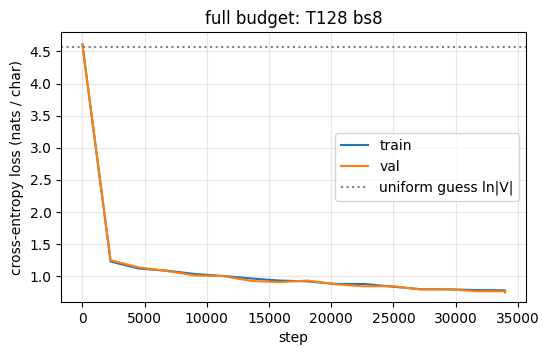

-> T128 bs8: fixed-slice validation loss 0.7700


In [78]:
run_extra("T128 bs8")

model: 481,344 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5720 | val loss 4.5704 | lr 1.50e-05 |    0.2s
step  1592 | train loss 1.3162 | val loss 1.3016 | lr 2.98e-03 |   18.9s
step  3184 | train loss 1.0773 | val loss 1.1242 | lr 2.90e-03 |   37.8s
step  4776 | train loss 1.0012 | val loss 1.0320 | lr 2.76e-03 |   56.7s
step  6368 | train loss 0.9610 | val loss 0.9399 | lr 2.57e-03 |   75.5s
step  7960 | train loss 0.9394 | val loss 0.9385 | lr 2.35e-03 |   94.1s
step  9552 | train loss 0.8959 | val loss 0.8848 | lr 2.09e-03 |  112.8s
step 11144 | train loss 0.8809 | val loss 0.8775 | lr 1.81e-03 |  131.5s
step 12736 | train loss 0.8681 | val loss 0.8582 | lr 1.53e-03 |  151.0s
step 14328 | train loss 0.8255 | val loss 0.8086 | lr 1.25e-03 |  169.6s
step 15920 | train loss 0.7878 | val loss 0.8199 | lr 9.86e-04 |  188.7s
step 17512 | train loss 0.7806 | val loss 0.7868 | lr 7.54e-04 |  207.2s
step 19104 | train loss 0.7515 | val loss 0.7

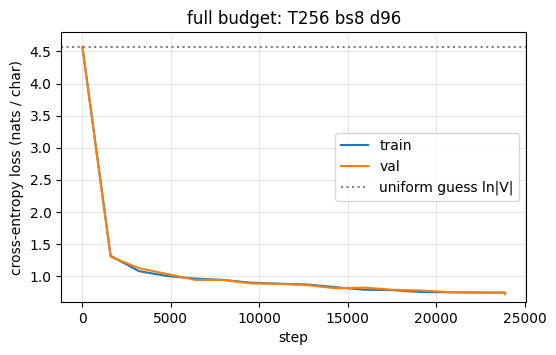

-> T256 bs8 d96: fixed-slice validation loss 0.7292


In [79]:
run_extra("T256 bs8 d96")

model: 1,234,944 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.5958 | val loss 4.5964 | lr 1.50e-05 |    0.2s
step   663 | train loss 1.8019 | val loss 1.8210 | lr 2.98e-03 |   11.6s
step  1326 | train loss 1.2977 | val loss 1.2856 | lr 2.91e-03 |   22.9s
step  1989 | train loss 1.0821 | val loss 1.1050 | lr 2.78e-03 |   34.2s
step  2652 | train loss 1.0176 | val loss 1.0579 | lr 2.60e-03 |   45.5s
step  3315 | train loss 1.0046 | val loss 0.9761 | lr 2.37e-03 |   56.9s
step  3978 | train loss 0.9185 | val loss 0.9391 | lr 2.12e-03 |   68.2s
step  4641 | train loss 0.9239 | val loss 0.9097 | lr 1.84e-03 |   79.7s
step  5304 | train loss 0.8615 | val loss 0.8790 | lr 1.55e-03 |   91.1s
step  5967 | train loss 0.8259 | val loss 0.8412 | lr 1.27e-03 |  102.2s
step  6630 | train loss 0.7908 | val loss 0.7811 | lr 1.00e-03 |  113.4s
step  7293 | train loss 0.7669 | val loss 0.7923 | lr 7.64e-04 |  124.8s
step  7956 | train loss 0.7207 | val loss 0

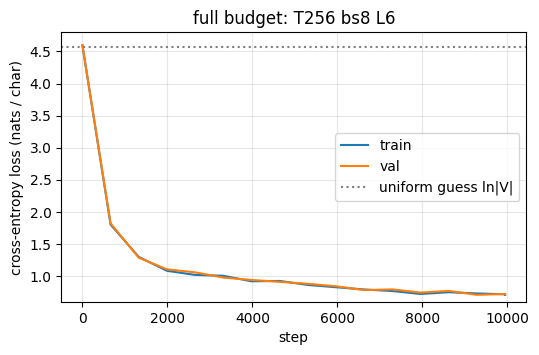

-> T256 bs8 L6: fixed-slice validation loss 0.7129


In [80]:
run_extra("T256 bs8 L6")

model: 1,847,424 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6180 | val loss 4.6189 | lr 1.50e-05 |    0.3s
step   500 | train loss 1.7502 | val loss 1.7416 | lr 2.99e-03 |    9.3s
step  1000 | train loss 1.3742 | val loss 1.3483 | lr 2.91e-03 |   18.3s
step  1500 | train loss 1.2041 | val loss 1.1930 | lr 2.78e-03 |   27.3s
step  2000 | train loss 1.1367 | val loss 1.1296 | lr 2.59e-03 |   36.3s
step  2500 | train loss 1.0983 | val loss 1.1257 | lr 2.35e-03 |   45.4s
step  3000 | train loss 1.0491 | val loss 1.0524 | lr 2.07e-03 |   54.5s
step  3500 | train loss 1.0076 | val loss 1.0106 | lr 1.78e-03 |   63.5s
step  4000 | train loss 0.9861 | val loss 0.9625 | lr 1.48e-03 |   72.6s
step  4500 | train loss 0.9278 | val loss 0.9473 | lr 1.19e-03 |   81.6s
step  5000 | train loss 0.9044 | val loss 0.8957 | lr 9.16e-04 |   90.7s
step  5500 | train loss 0.8697 | val loss 0.8695 | lr 6.83e-04 |   99.8s
step  6000 | train loss 0.8517 | val loss 0

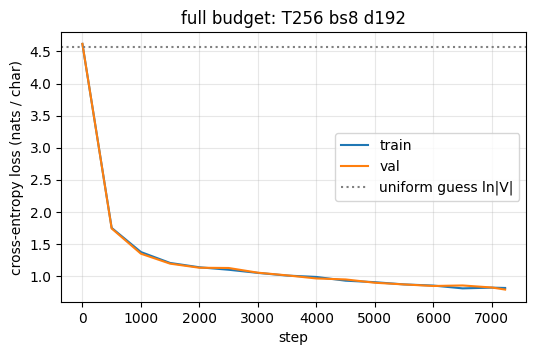

-> T256 bs8 d192: fixed-slice validation loss 0.8142


In [81]:
run_extra("T256 bs8 d192")

### B4a · Dropout at the winning setting

model: 838,400 parameters | compute: 1.99e+14 FLOPs (99% of the Part 7 budget)
step     0 | train loss 4.6083 | val loss 4.6080 | lr 1.50e-05 |    0.2s
step   981 | train loss 1.4203 | val loss 1.4181 | lr 2.98e-03 |   12.5s
step  1962 | train loss 1.2191 | val loss 1.2180 | lr 2.90e-03 |   24.9s
step  2943 | train loss 1.0851 | val loss 1.0904 | lr 2.77e-03 |   37.2s
step  3924 | train loss 1.0533 | val loss 1.0453 | lr 2.58e-03 |   49.3s
step  4905 | train loss 0.9888 | val loss 0.9932 | lr 2.36e-03 |   61.4s
step  5886 | train loss 0.9414 | val loss 0.9420 | lr 2.10e-03 |   73.5s
step  6867 | train loss 0.9296 | val loss 0.8906 | lr 1.82e-03 |   85.6s
step  7848 | train loss 0.9082 | val loss 0.8958 | lr 1.54e-03 |   97.9s
step  8829 | train loss 0.8656 | val loss 0.8402 | lr 1.26e-03 |  110.0s
step  9810 | train loss 0.8295 | val loss 0.8613 | lr 9.92e-04 |  122.2s
step 10791 | train loss 0.8162 | val loss 0.8422 | lr 7.58e-04 |  134.5s
step 11772 | train loss 0.8327 | val loss 0.8

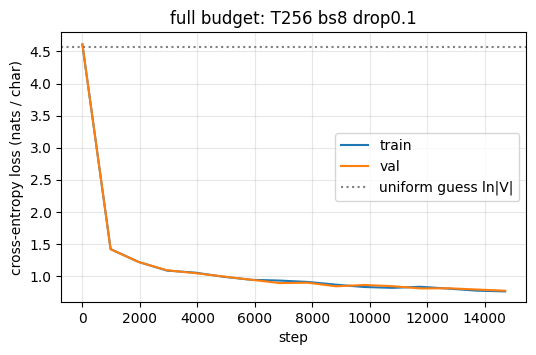

-> T256 bs8 drop0.1: fixed-slice validation loss 0.7826


In [82]:
run_extra("T256 bs8 drop0.1")

### B4b · RoPE at the full budget

The RoPE model has no position table, so it has 16,384 fewer parameters. To keep the comparison exact, it gets **the same number of steps, the same batch and the same learning rate** as the learned-position winner (`T256 bs8`, 14,715 steps); it therefore uses slightly less than the budget. The learned-position reference values are the three seeds of Part 7.6.

In [83]:
ROPE_FULL = {}


def rope_full(seed):
    tc_ = full_training_config("T256 bs8")                 # same steps / batch / lr as the learned winner
    m_, _ = train_rope(FULL_PLAN["T256 bs8"][0], tc_, seed=seed, name=f"RoPE full seed {seed}")
    ROPE_FULL[seed] = fixed_slice_loss(m_)
    print(f"-> RoPE T256 bs8, seed {seed}: fixed-slice validation loss {ROPE_FULL[seed]:.4f} (learned: {LEARNED_T256[seed]:.4f})")
    del m_
    if device == "cuda":
        torch.cuda.empty_cache()

In [84]:
rope_full(1337)

RoPE model: 805,632 parameters | compute: 1.93e+14 FLOPs (97% of the budget)
step     0 | train loss 4.5710 | val loss 4.5687 | lr 1.50e-05 |    0.2s
step   500 | train loss 1.3805 | val loss 1.3727 | lr 3.00e-03 |    8.0s
step  1000 | train loss 1.1814 | val loss 1.1821 | lr 2.98e-03 |   15.1s
step  1500 | train loss 1.0866 | val loss 1.0872 | lr 2.95e-03 |   23.1s
step  2000 | train loss 1.0706 | val loss 1.0522 | lr 2.90e-03 |   30.3s
step  2500 | train loss 1.0068 | val loss 1.0056 | lr 2.84e-03 |   38.3s
step  3000 | train loss 0.9936 | val loss 1.0025 | lr 2.76e-03 |   46.2s
step  3500 | train loss 0.9448 | val loss 0.9471 | lr 2.67e-03 |   53.3s
step  4000 | train loss 0.9455 | val loss 0.9404 | lr 2.57e-03 |   61.2s
step  4500 | train loss 0.9307 | val loss 0.8927 | lr 2.46e-03 |   68.8s
step  5000 | train loss 0.9205 | val loss 0.8935 | lr 2.33e-03 |   76.6s
step  5500 | train loss 0.8878 | val loss 0.8867 | lr 2.21e-03 |   84.5s
step  6000 | train loss 0.8708 | val loss 0.877

In [85]:
rope_full(1)

RoPE model: 805,632 parameters | compute: 1.93e+14 FLOPs (97% of the budget)
step     0 | train loss 4.6448 | val loss 4.6414 | lr 1.50e-05 |    0.2s
step   500 | train loss 1.3495 | val loss 1.3884 | lr 3.00e-03 |    8.1s
step  1000 | train loss 1.1672 | val loss 1.2023 | lr 2.98e-03 |   15.9s
step  1500 | train loss 1.0779 | val loss 1.0741 | lr 2.95e-03 |   23.3s
step  2000 | train loss 1.0398 | val loss 1.0477 | lr 2.90e-03 |   31.3s
step  2500 | train loss 1.0016 | val loss 1.0054 | lr 2.84e-03 |   38.5s
step  3000 | train loss 0.9870 | val loss 0.9872 | lr 2.76e-03 |   46.6s
step  3500 | train loss 0.9637 | val loss 0.9482 | lr 2.67e-03 |   54.7s
step  4000 | train loss 0.9038 | val loss 0.9330 | lr 2.57e-03 |   62.0s
step  4500 | train loss 0.8718 | val loss 0.8976 | lr 2.46e-03 |   70.0s
step  5000 | train loss 0.8980 | val loss 0.9060 | lr 2.33e-03 |   77.5s
step  5500 | train loss 0.8918 | val loss 0.8770 | lr 2.21e-03 |   85.2s
step  6000 | train loss 0.8576 | val loss 0.867

In [86]:
rope_full(2)

RoPE model: 805,632 parameters | compute: 1.93e+14 FLOPs (97% of the budget)
step     0 | train loss 4.5747 | val loss 4.5722 | lr 1.50e-05 |    0.2s
step   500 | train loss 1.3842 | val loss 1.3954 | lr 3.00e-03 |    7.4s
step  1000 | train loss 1.2364 | val loss 1.2229 | lr 2.98e-03 |   15.4s
step  1500 | train loss 1.1479 | val loss 1.1301 | lr 2.95e-03 |   22.8s
step  2000 | train loss 1.0802 | val loss 1.0617 | lr 2.90e-03 |   30.5s
step  2500 | train loss 1.0069 | val loss 1.0050 | lr 2.84e-03 |   38.4s
step  3000 | train loss 1.0036 | val loss 0.9932 | lr 2.76e-03 |   45.7s
step  3500 | train loss 0.9572 | val loss 0.9658 | lr 2.67e-03 |   53.8s
step  4000 | train loss 0.9258 | val loss 0.9279 | lr 2.57e-03 |   61.6s
step  4500 | train loss 0.9386 | val loss 0.9268 | lr 2.46e-03 |   69.1s
step  5000 | train loss 0.9171 | val loss 0.9170 | lr 2.33e-03 |   77.2s
step  5500 | train loss 0.9023 | val loss 0.9211 | lr 2.21e-03 |   85.1s
step  6000 | train loss 0.8815 | val loss 0.874

In [87]:
seeds_ = (1337, 1, 2)
learned_ = [LEARNED_T256[s] for s in seeds_]; rope_ = [ROPE_FULL[s] for s in seeds_]
t_, p_ = stats.ttest_ind(learned_, rope_, equal_var=False)
print(f"{'':10s} {'seed 1337':>10s} {'seed 1':>8s} {'seed 2':>8s} | {'mean':>8s} {'std':>7s}")
print(f"{'learned':10s} " + " ".join(f"{v:8.4f}" for v in learned_) + f" | {st.mean(learned_):8.4f} {st.stdev(learned_):7.4f}")
print(f"{'RoPE':10s} " + " ".join(f"{v:8.4f}" for v in rope_) + f" | {st.mean(rope_):8.4f} {st.stdev(rope_):7.4f}")
print(f"\nmean gap (learned - RoPE): {st.mean(learned_) - st.mean(rope_):+.4f} | Welch t = {t_:.2f}, p = {p_:.3f}")
print("every RoPE seed below every learned seed:", max(rope_) < min(learned_))
print("per-seed gaps (same seed):", [f"{l - r:+.4f}" for l, r in zip(learned_, rope_)])

            seed 1337   seed 1   seed 2 |     mean     std
learned      0.7016   0.7077   0.7088 |   0.7060  0.0038
RoPE         0.7260   0.7217   0.7160 |   0.7212  0.0050

mean gap (learned - RoPE): -0.0152 | Welch t = -4.18, p = 0.016
every RoPE seed below every learned seed: False
per-seed gaps (same seed): ['-0.0244', '-0.0140', '-0.0073']


### B2 · How much of the gain is the scoring? (no training)

Part 8 cuts the validation slice into windows of the model's **own** `block_size`. A model with a longer window is scored on windows in which a smaller share of the characters sit near the start, where prediction is hardest. To separate this from a better model, `window_loss` scores the **same trained model** with different window lengths (a model with `block_size` $T$ can be scored with any window $\le T$). The 🔒 Part 8 evaluation is not touched.

In [88]:
@torch.no_grad()
def window_loss(m, window, n_chars=1_000_000, batch_size=32):
    # mean loss over the first n_chars validation characters, cut into consecutive windows of `window` characters
    assert window <= m.config.block_size
    m.eval()
    n_windows = n_chars // window
    data = val_data[: n_windows * window + 1].long()
    x_all, y_all = data[:-1].view(n_windows, window), data[1:].view(n_windows, window)
    total = 0.0
    for i in range(0, n_windows, batch_size):
        x, y = x_all[i : i + batch_size].to(device), y_all[i : i + batch_size].to(device)
        logits, _ = m(x)
        total += F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="sum").item()
    m.train()
    return total / (n_windows * window)


ref_ = {"T128 bs32 (baseline)": FULL_MODELS["T128 bs32 (baseline)"], "T256 bs8 (winner)": FULL_MODELS["T256 bs8"]}
if "T128 bs8" in EXTRA_MODELS:
    ref_["T128 bs8"] = EXTRA_MODELS["T128 bs8"]
for k_, m_ in ref_.items():   # sanity check: with window = block_size this reproduces the Part 8 number
    assert abs(window_loss(m_, m_.config.block_size) - fixed_slice_loss(m_)) < 1e-4, "window_loss disagrees with fixed_slice_loss"

WINDOWS = [32, 64, 128, 256]
WL = {k_: {w_: window_loss(m_, w_) for w_ in WINDOWS if w_ <= m_.config.block_size} for k_, m_ in ref_.items()}
print(f"{'model (block_size)':28s}" + "".join(f"{'window ' + str(w_):>11s}" for w_ in WINDOWS))
for k_, m_ in ref_.items():
    print(f"{k_ + ' (' + str(m_.config.block_size) + ')':28s}" + "".join(f"{WL[k_][w_]:11.4f}" if w_ in WL[k_] else f"{'-':>11s}" for w_ in WINDOWS))

base_, win_ = WL["T128 bs32 (baseline)"], WL["T256 bs8 (winner)"]
total_ = win_[256] - base_[128]          # what Part 8 measures: each model scored with its own window
scoring_ = win_[256] - win_[128]         # same trained model, window 256 instead of 128
model_ = win_[128] - base_[128]          # both models scored with the same 128-character windows
print(f"\nPart 8 difference (T256 bs8 at 256  -  baseline at 128)    : {total_:+.4f}")
print(f"  = scoring effect (winner at 256  -  winner at 128)       : {scoring_:+.4f}   ({scoring_ / total_:.0%} of the gain)")
print(f"  + model effect   (winner at 128  -  baseline at 128)     : {model_:+.4f}   ({model_ / total_:.0%} of the gain)")

model (block_size)            window 32  window 64 window 128 window 256
T128 bs32 (baseline) (128)       0.9033     0.8077     0.7478          -
T256 bs8 (winner) (256)          0.9274     0.8246     0.7532     0.7016
T128 bs8 (128)                   0.9221     0.8270     0.7700          -

Part 8 difference (T256 bs8 at 256  -  baseline at 128)    : -0.0462
  = scoring effect (winner at 256  -  winner at 128)       : -0.0516   (112% of the gain)
  + model effect   (winner at 128  -  baseline at 128)     : +0.0054   (-12% of the gain)


### Summary of all full-budget settings

Every row is one `train()` run with 99.5% of the budget (seed 1337). *tokens* is the number of characters processed, *tokens/param* the ratio of training characters to parameters.

setting                   params   steps  tokens (M)  tokens/param  fixed-slice loss  vs T256 bs8
T256 bs8                 838,400  14,715        30.1          35.9            0.7016      +0.0000
T256 bs16 lr4e-3         838,400   7,357        30.1          35.9            0.7067      +0.0050
T256 bs8 L6            1,234,944   9,946        20.4          16.5            0.7129      +0.0113
T384 bs8                 854,784   8,650        26.6          31.1            0.7211      +0.0195
T512 bs8                 871,168   5,802        23.8          27.3            0.7251      +0.0234
T256 bs8 d96             481,344  23,887        48.9         101.6            0.7292      +0.0275
T256 bs16                838,400   7,357        30.1          35.9            0.7343      +0.0327
T128 bs32 (baseline)     822,016   8,495        34.8          42.3            0.7478      +0.0462
T128 bs8                 822,016  33,983        34.8          42.3            0.7700      +0.0684
T256 bs8 drop0.1    

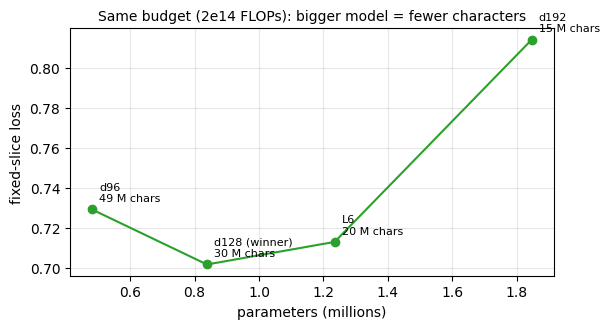

No Appendix B setting beats the Part 7 final model ('T256 bs8', 0.7016); best of Appendix B: 'T256 bs8 L6' 0.7129.


In [89]:
rows_ = []
for name_, (cfg_, kw_) in FULL_PLAN.items():
    if name_ not in FULL_LOSS:      # (only the two reference runs exist when the stand-alone runner is used)
        continue
    tc_ = FULL_TC[name_]; rows_.append((name_, FULL_MODELS[name_].num_params(), tc_.max_steps, tc_.batch_size * cfg_.block_size * tc_.max_steps, FULL_LOSS[name_]))
for name_ in B_PLAN:
    if name_ in EXTRA_LOSS:
        tc_ = EXTRA_TC[name_]; rows_.append((name_, EXTRA_MODELS[name_].num_params(), tc_.max_steps, tc_.batch_size * B_PLAN[name_][0].block_size * tc_.max_steps, EXTRA_LOSS[name_]))
rows_.sort(key=lambda r: r[4])
print(f"{'setting':22s} {'params':>9s} {'steps':>7s} {'tokens (M)':>11s} {'tokens/param':>13s} {'fixed-slice loss':>17s} {'vs T256 bs8':>12s}")
for n_, p_, s_, t_, l_ in rows_:
    print(f"{n_:22s} {p_:9,d} {s_:7,d} {t_ / 1e6:11.1f} {t_ / p_:13.1f} {l_:17.4f} {l_ - FULL_LOSS['T256 bs8']:+12.4f}")

# the size / tokens trade-off at context 256, batch 8, lr 3e-3
fam_ = {"d96": EXTRA_LOSS.get("T256 bs8 d96"), "d128 (winner)": FULL_LOSS["T256 bs8"], "L6": EXTRA_LOSS.get("T256 bs8 L6"), "d192": EXTRA_LOSS.get("T256 bs8 d192")}
fam_models_ = {"d96": EXTRA_MODELS.get("T256 bs8 d96"), "d128 (winner)": FULL_MODELS["T256 bs8"], "L6": EXTRA_MODELS.get("T256 bs8 L6"), "d192": EXTRA_MODELS.get("T256 bs8 d192")}
fam_ = {k: v for k, v in fam_.items() if v is not None}
xs_ = [fam_models_[k].num_params() / 1e6 for k in fam_]; ys_ = list(fam_.values())
plt.figure(figsize=(6.2, 3.4))
plt.plot(xs_, ys_, "o-", color="tab:green")
for k_, x_, y_ in zip(fam_, xs_, ys_):
    tok_ = (FULL_TC["T256 bs8"] if k_ == "d128 (winner)" else EXTRA_TC["T256 bs8 " + k_]).max_steps * 8 * 256 / 1e6
    plt.annotate(f"{k_}\n{tok_:.0f} M chars", (x_, y_), textcoords="offset points", xytext=(5, 6), fontsize=8)
plt.xlabel("parameters (millions)"); plt.ylabel("fixed-slice loss"); plt.grid(alpha=0.3)
plt.title("Same budget (2e14 FLOPs): bigger model = fewer characters", fontsize=10); plt.tight_layout(); plt.show()

best_new_ = min(EXTRA_LOSS, key=EXTRA_LOSS.get)
if EXTRA_LOSS[best_new_] < FULL_LOSS["T256 bs8"]:
    print(f"NOTE: '{best_new_}' ({EXTRA_LOSS[best_new_]:.4f}) beats the Part 7 final model ({FULL_LOSS['T256 bs8']:.4f}).")
    print("      To submit it instead, set final_model = EXTRA_MODELS['" + best_new_ + "'] in Part 8 (it was trained with train(), so Part 8 accepts it).")
else:
    print(f"No Appendix B setting beats the Part 7 final model ('T256 bs8', {FULL_LOSS['T256 bs8']:.4f}); best of Appendix B: '{best_new_}' {EXTRA_LOSS[best_new_]:.4f}.")

### Appendix B · Welch test for the 35%-budget RoPE comparison of Appendix A

Appendix A quoted a Welch p-value that was computed outside the notebook. Here it is, printed from the same six numbers.

In [90]:
_S = globals().get("SEEDS", {})
a_learned = [_S.get(("learned", s), v) for s, v in zip((1337, 1, 2), (0.8570, 0.8567, 0.8544))]
a_rope = [_S.get(("rope", s), v) for s, v in zip((1337, 1, 2), (0.8437, 0.8473, 0.8510))]
t_a, p_a = stats.ttest_ind(a_learned, a_rope, equal_var=False)
print(f"35% budget: learned {st.mean(a_learned):.4f} +/- {st.stdev(a_learned):.4f} | RoPE {st.mean(a_rope):.4f} +/- {st.stdev(a_rope):.4f} | "
      f"gap {st.mean(a_learned) - st.mean(a_rope):+.4f} | Welch t = {t_a:.2f}, p = {p_a:.3f}")

35% budget: learned 0.8555 +/- 0.0026 | RoPE 0.8476 +/- 0.0032 | gap +0.0079 | Welch t = 3.31, p = 0.031


---
### Final results at a glance

| Item | Result |
|---|---|
| Default model (3,000 steps, 35% of the budget), fixed validation slice | **0.8585** nats/char (requirement ≤ 1.00 ✅); `estimate_loss` 0.8495 |
| Part 7 final model: `T256 bs8` (4 layers, d = 128, context 256, batch 8, 14,715 steps, 99.5% of `FLOP_BUDGET`) | **0.7016** nats/char = 1.0123 bits/char, perplexity 2.017 → score tier ≤ 0.725 (20 points) |
| Compute of the final run | 1.99 × 10¹⁴ FLOPs ≤ 2 × 10¹⁴ ✅, trained with `train()` ✅ |
| Same setting on fresh seeds | 0.7077 and 0.7088 (all three seeds below 0.725); the baseline `T128 bs32` scores 0.7478, 0.7535 and 0.7553 |
| Context length (full budget, seed 1337) | 128: 0.7478 · 256 (batch 16): 0.7343 · 256 (batch 8): 0.7016 · 384: 0.7211 · 512: 0.7251 |
| 12% screening against the full budget | `context 256` was the worst in screening (1.2821 against 1.1050) and better than the baseline at the full budget (0.7343 against 0.7478) |
| Bonus, Option B (RoPE), 35% of the budget, 3 seeds each | **0.8476 ± 0.0032** against 0.8555 ± 0.0026 for learned positions; every RoPE seed is better (Welch p = 0.031) |
| RoPE at the full budget (Appendix B, `T256 bs8`, 3 seeds) | 0.7212 ± 0.0050 against 0.7060 ± 0.0038 for learned positions: RoPE is **worse** here (Welch p = 0.016) |
| Window-length analysis (Appendix B) | with equal 128-character windows the winner (0.7532) is not better than the baseline (0.7478); the window length alone explains the whole Part 8 difference (−0.0516 against −0.0462 in total) |
| Model size at the same budget (Appendix B, `T256 bs8`) | width 96: 0.7292 · **width 128 (winner): 0.7016** · 6 layers: 0.7129 · width 192: 0.8142 · dropout 0.1: 0.7826 · context 128 with batch 8: 0.7700 |
| Tests | all 10 TODO test cells ✅; RoPE tests ✅ |

---
### References

- A. Karpathy, *nanoGPT* (2022), [github.com/karpathy/nanoGPT](https://github.com/karpathy/nanoGPT), and the video *Let's build GPT: from scratch, in code, spelled out*.
- A. Vaswani et al., *Attention Is All You Need* (2017).
- A. Radford et al., *Language Models are Unsupervised Multitask Learners* (GPT-2, 2019).
- R. Eldan & Y. Li, *TinyStories: How Small Can Language Models Be and Still Speak Coherent English?* (2023).
- J. Kaplan et al., *Scaling Laws for Neural Language Models* (2020); J. Hoffmann et al., *Training Compute-Optimal Large Language Models* (2022).
- J. Su et al., *RoFormer: Enhanced Transformer with Rotary Position Embedding* (2021).
- G. Penedo et al., *The FineWeb Datasets* (2024).